# RAG Evaluation Metrics — Exploration

Loads Langfuse parquet exports from `local/metric-export/` and provides structured analysis across four sections:

1. **Single run** — deep-dive on one session
2. **Multiple runs** — compare configurations via `run_id`
3. **Stability** — compare repeated sessions of the same `run_id`
4. **Statistics** — per-session descriptive stats for a given `run_id`

**Run the export first, for example:**
```bash
python analysis/langfuse_export.py --session-id <your_session_id>
```

## Setup & Data Loading

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Make utils importable from notebook dir
sys.path.insert(0, str(Path.cwd()))

from utils import (
    load_files,
    get_session_ids,
    get_run_ids,
    print_dataset_info,
    plot_boxplot,
    plot_boxplots,
    plot_metrics_grid,
    plot_latency_as_hist,
    plot_generation_as_hist,
    plot_retrieval_as_hist,
    plot_hardware_as_hist,
    plot_generation_quality_as_hist,
    plot_scatter_two_metrics,
    stats_by_group,
    plot_stats_bar,
    plot_stats_line,
    plot_stats_multi_line,
    find_outliers,
    exclude_outliers,
    _present,
    _numeric_metric_cols,
    LATENCY_COLS,
    GENERATION_COLS,
    RETRIEVAL_COLS,
    HARDWARE_COLS,
    GENERATION_QUALITY_COLS,
)

EXPORT_DIR = Path("../local/metric-export/eval1")

### Load dataset(s)

Adjust `folder` / `pattern` or pass explicit `paths` to `load_files()`.  
The cell prints all session IDs, run IDs, and column names.

In [6]:
# Load all exports matching a pattern, or pass explicit paths=["file1.parquet", ...]
df = load_files(folder=EXPORT_DIR, pattern="*langfuse_export*.parquet")

print_dataset_info(df)

Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q4_61_40085d87.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q4_61_79ef3626.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q5_61_23c47ab9.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q5_61_f096093a.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q8_61_2a62bc35.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q8_61_73db2260.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q4_61_5b437b29.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q4_61_e4176cee.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q5_61_907aac99.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q5_61_d4b17c70.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_mist

## Quick NaN & Outlier Analysis

In [7]:
# metric_cols: numeric, non-boolean metric columns (safe for quantile ops)
metric_cols = _numeric_metric_cols(df)

# --- NaN counts ---
nan_counts = df[metric_cols].isna().sum()
nan_pct = (nan_counts / len(df) * 100).round(1)
nan_df = pd.DataFrame({"nan_count": nan_counts, "nan_pct": nan_pct})
nan_df = nan_df[nan_df["nan_count"] > 0].sort_values("nan_pct", ascending=False)

if nan_df.empty:
    print("No NaNs in metric columns.")
else:
    print("Columns with NaN values:")
    display(nan_df)

Columns with NaN values:


,nan_count,nan_pct
score_Faithfulness custom,9,0.8
score_Evaluate Hallucination V2,9,0.8
score_Correctness,2,0.2


In [8]:
# --- Outlier detection (IQR method, flag extreme values) ---
outlier_summary = {}
for col in metric_cols:
    series = df[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    n_outliers = ((series < (q1 - 3 * iqr)) | (series > (q3 + 3 * iqr))).sum()
    if n_outliers > 0:
        outlier_summary[col] = {"outliers (3×IQR)": n_outliers, "pct": round(n_outliers / len(series) * 100, 1)}

if outlier_summary:
    print("Columns with extreme outliers (|z| > 3×IQR):")
    display(pd.DataFrame(outlier_summary).T.sort_values("pct", ascending=False))
else:
    print("No extreme outliers detected.")

Columns with extreme outliers (|z| > 3×IQR):


,outliers (3×IQR),pct
hardware_swap_in_bytes,89.0,7.7
hardware_swap_out_bytes,45.0,3.9
hardware_avg_cpu_utilization_pct,20.0,1.7
latency_retrieval_latency_ms,5.0,0.4
latency_ms,4.0,0.3
latency_llm_generation_latency_ms,2.0,0.2
latency_predicted_ms,2.0,0.2
latency_predicted_per_token_ms,2.0,0.2
latency_ttft_ms,1.0,0.1
latency_prompt_ms,1.0,0.1


### Outlier Inspection

`find_outliers` returns a table of all rows flagged as outliers, annotated with the triggering column, its value, and the computed bounds. Use `exclude_outliers` to produce a cleaned copy of the DataFrame.

In [9]:
# Inspect outliers across all numeric metric columns.
# Tune `method` ("iqr" or "zscore") and `threshold` to adjust sensitivity.
outliers = find_outliers(df, method="iqr", threshold=3.0)

if outliers.empty:
    print("No outliers detected.")
else:
    print(f"{len(outliers)} outlier row(s) found across {outliers['outlier_col'].nunique()} column(s).\n")
    display(outliers)

172 outlier row(s) found across 11 column(s).



,outlier_col,value,lower,upper,session_id,run_id,claim_id,trace_id,latency_ms,latency_ttft_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Faithfulness custom,score_Correctness,score_Evaluate Hallucination V2
33,hardware_avg_cpu_utilization_pct,70.300000,-2.3250,28.3000,e5_large_test_mistral_7B_0_3_q8_61_440616f1,e5_large_test_mistral_7B_0_3_q8_61,emanual_284,a8415aecf2b19e2841e398895c9d0055,8101.0,1826.832961,...,0.333333,1.000000,8080.996250,11364.125000,70.30,108412928,901120,0.571000,0.20,0.10
18,hardware_avg_cpu_utilization_pct,68.750000,-2.3250,28.3000,e5_large_test_ministral_3_3B_q4_61_40085d87,e5_large_test_ministral_3_3B_q4_61,emanual_631,cbe0d28b268d6c9484dbb4479a26d50e,6815.0,1080.488180,...,0.500000,1.000000,6807.382833,7612.125000,68.75,24821760,1359872,0.600000,1.00,0.30
25,hardware_avg_cpu_utilization_pct,67.650000,-2.3250,28.3000,e5_large_test_ministral_3_8B_q5_61_907aac99,e5_large_test_ministral_3_8B_q5_61,emanual_59,1486d1b2bf6bc3abec5792e3d19cd504,18575.0,3975.480754,...,0.400000,0.500000,18534.093667,10310.109375,67.65,286900224,2326528,1.000000,0.25,0.85
27,hardware_avg_cpu_utilization_pct,67.450000,-2.3250,28.3000,e5_large_test_ministral_3_8B_q5_61_d4b17c70,e5_large_test_ministral_3_8B_q5_61,emanual_176,d3b813751967a6569a8d07305903e6b2,16301.0,2088.500754,...,0.250000,1.000000,16281.758708,10178.015625,67.45,477396992,1900544,1.000000,0.30,0.05
30,hardware_avg_cpu_utilization_pct,65.650000,-2.3250,28.3000,e5_large_test_mistral_7B_0_3_q3l_61_9d8f2a97,e5_large_test_mistral_7B_0_3_q3l_61,emanual_1,45fde578709480c8b1c3a269c8b30d1a,8641.0,2883.751942,...,0.200000,0.166667,8625.919125,8478.140625,65.65,21217280,606208,1.000000,0.20,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,latency_retrieval_latency_ms,1042.123125,-69.0468,246.5778,e5_large_test_ministral_3_3B_q4_61_467677c6,e5_large_test_ministral_3_3B_q4_61,emanual_467,a18b68bf9deb762e4e773194e6f8820b,10133.0,1553.854807,...,0.500000,1.000000,10119.960667,7521.781250,10.50,2471706624,655360,0.857000,1.00,0.00
12,latency_retrieval_latency_ms,497.492250,-69.0468,246.5778,e5_large_test_ministral_3_8B_q5_61_d4b17c70,e5_large_test_ministral_3_8B_q5_61,emanual_637,1d92ee835021c61bc2848e6137b99cf5,18099.0,3444.286535,...,0.250000,1.000000,18062.994708,10122.265625,18.95,168787968,1310720,1.000000,0.10,0.15
14,latency_retrieval_latency_ms,450.378833,-69.0468,246.5778,e5_large_test_ministral_3_8B_q5_61_d4b17c70,e5_large_test_ministral_3_8B_q5_61,emanual_188,3cb65a44a0f6d90cb4359e02bd307e45,16200.0,3218.740858,...,0.600000,1.000000,16112.407584,10366.906250,21.95,743751680,5144576,0.888889,0.60,0.65
13,latency_retrieval_latency_ms,247.221834,-69.0468,246.5778,e5_large_test_ministral_3_8B_q5_61_d4b17c70,e5_large_test_ministral_3_8B_q5_61,emanual_14,3e2428e35e818518ce57b8fd6133b83b,11160.0,2992.242780,...,0.333333,1.000000,11132.398292,10376.171875,23.85,445005824,3686400,0.571000,1.00,0.60


In [ ]:
# Narrow the inspection to specific columns if needed, e.g. latency only:
#   find_outliers(df, cols=LATENCY_COLS, method="iqr", threshold=3.0)

# Exclude outliers and continue analysis with the cleaned frame.
# Adjust cols to limit exclusion to a specific metric group:
#   df_clean = exclude_outliers(df, cols=LATENCY_COLS)
df_clean = exclude_outliers(df, method="iqr", threshold=3.0)
print(f"Clean shape: {df_clean.shape}")

---
# 1  Single Run Analysis

One parquet file = one session. Select a `SESSION_ID` below to drill into all traces for that session.

In [10]:
# Set the session to inspect (copy from the printed list above)
SESSION_ID = get_session_ids(df)[0]  # default: first session; replace with a string literal

df_single = df[df["session_id"] == SESSION_ID].copy()
print(f"Session: {SESSION_ID}")
print(f"Traces:  {len(df_single)}")

Session: e5_large_test_ministral_3_3B_q4_61_40085d87
Traces:  61


## 1.1  Head

In [11]:
df_single.head()

,trace_id,session_id,observation_id,start_time,end_time,latency_ms,run_id,claim_id,langfuse_observation_type,latency_ttft_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Faithfulness custom,score_Correctness,score_Evaluate Hallucination V2
0,52548b8500b99509f35201c049c5bf4e,e5_large_test_ministral_3_3B_q4_61_40085d87,ad3261a8f466cf9c,2026-03-10 10:57:33.466000+00:00,2026-03-10 10:57:40.108000+00:00,6642.0,e5_large_test_ministral_3_3B_q4_61,emanual_114,generation,1272.770605,...,0.5,1.0,6640.527083,7924.859375,10.90,26771456,1032192,0.571429,0.60,0.10
1,f501d869a2034a56e3e0fb5e0cfd5afe,e5_large_test_ministral_3_3B_q4_61_40085d87,98754f9269131a32,2026-03-10 10:57:27.219000+00:00,2026-03-10 10:57:33.466000+00:00,6247.0,e5_large_test_ministral_3_3B_q4_61,emanual_333,generation,864.282445,...,0.6,1.0,6244.249375,7847.984375,12.75,81756160,1245184,1.000000,0.65,0.00
2,cbe0d28b268d6c9484dbb4479a26d50e,e5_large_test_ministral_3_3B_q4_61_40085d87,221c119ea9041521,2026-03-10 10:57:20.403000+00:00,2026-03-10 10:57:27.218000+00:00,6815.0,e5_large_test_ministral_3_3B_q4_61,emanual_631,generation,1080.488180,...,0.5,1.0,6807.382833,7612.125000,68.75,24821760,1359872,0.600000,1.00,0.30
3,f446a77106938d622e8166c56103b215,e5_large_test_ministral_3_3B_q4_61_40085d87,1fa67a461a155938,2026-03-10 10:57:15.405000+00:00,2026-03-10 10:57:20.403000+00:00,4998.0,e5_large_test_ministral_3_3B_q4_61,emanual_283,generation,803.363964,...,0.4,1.0,4991.806750,7324.812500,13.70,3178496,16384,1.000000,1.00,0.05
4,8f35a027198b93c938f4d2c56747198b,e5_large_test_ministral_3_3B_q4_61_40085d87,e9eb68a730f7d0fc,2026-03-10 10:57:08.544000+00:00,2026-03-10 10:57:15.405000+00:00,6861.0,e5_large_test_ministral_3_3B_q4_61,emanual_465,generation,1456.379988,...,0.6,1.0,6858.146000,7324.000000,10.15,2244608,294912,0.560000,0.40,0.30


## 1.2  Summary Statistics

In [12]:
single_metric_cols = _numeric_metric_cols(df_single)
df_single[single_metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
latency_ms,61.0,5.618213e+03,1.373036e+03,1932.000000,4.919000e+03,6.250000e+03,6.623000e+03,8.535000e+03
latency_ttft_ms,61.0,1.090417e+03,2.125001e+02,543.437980,9.746878e+02,1.119076e+03,1.214160e+03,1.581996e+03
latency_llm_generation_latency_ms,61.0,4.402732e+03,1.303850e+03,769.868000,3.799326e+03,5.309138e+03,5.349174e+03,5.626670e+03
latency_prompt_ms,61.0,1.069535e+03,2.124455e+02,522.961000,9.541090e+02,1.098381e+03,1.193041e+03,1.561112e+03
latency_predicted_ms,61.0,4.402732e+03,1.303850e+03,769.868000,3.799326e+03,5.309138e+03,5.349174e+03,5.626670e+03
latency_predicted_per_token_ms,61.0,2.088268e+01,2.458135e-01,20.476980,2.071234e+01,2.086845e+01,2.097011e+01,2.197918e+01
generation_prompt_tokens,61.0,5.200492e+02,9.640011e+01,351.000000,4.520000e+02,5.210000e+02,5.780000e+02,7.480000e+02
generation_completion_tokens,61.0,2.107705e+02,6.223327e+01,37.000000,1.810000e+02,2.560000e+02,2.560000e+02,2.560000e+02
generation_tokens_per_second,61.0,4.789296e+01,5.510016e-01,45.497603,4.768693e+01,4.791924e+01,4.828041e+01,4.883533e+01
latency_retrieval_latency_ms,61.0,7.464618e+01,2.678790e+01,28.144333,5.613017e+01,7.816129e+01,9.642179e+01,1.479039e+02


## 1.3  Metric Plots

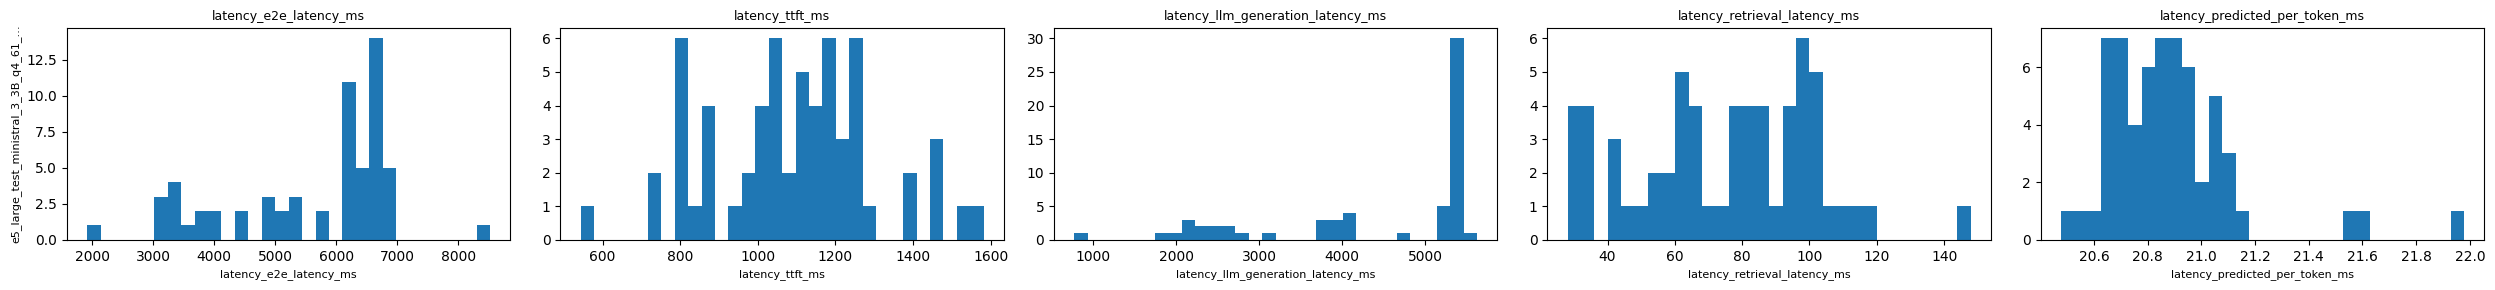

In [13]:
plot_latency_as_hist(df_single)

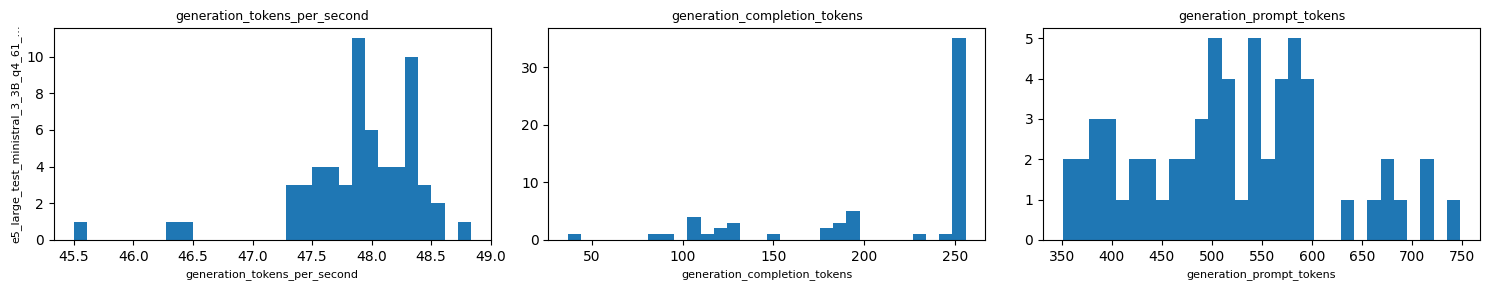

In [14]:
plot_generation_as_hist(df_single)

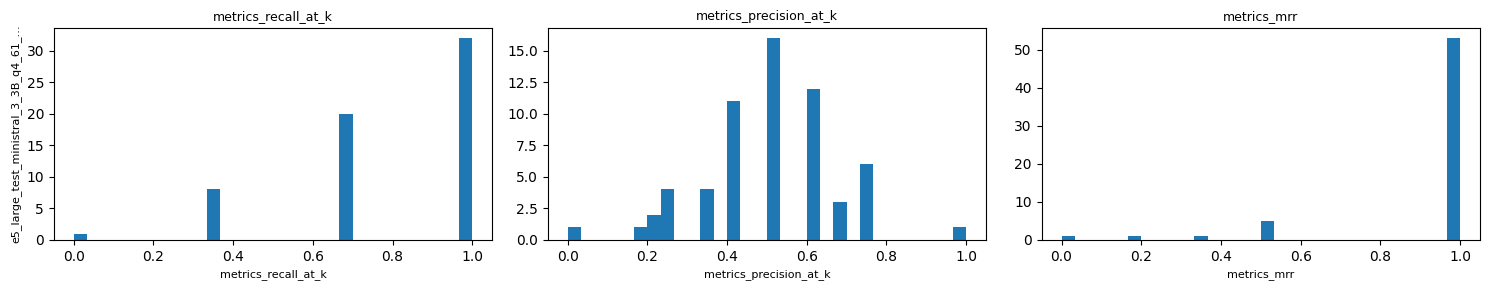

In [15]:
plot_retrieval_as_hist(df_single)

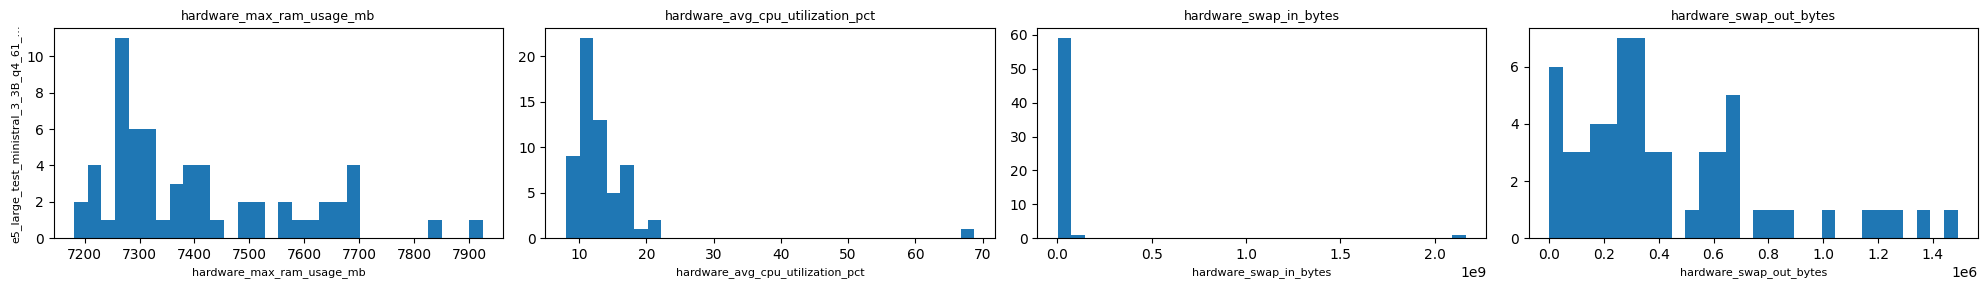

In [16]:
plot_hardware_as_hist(df_single)

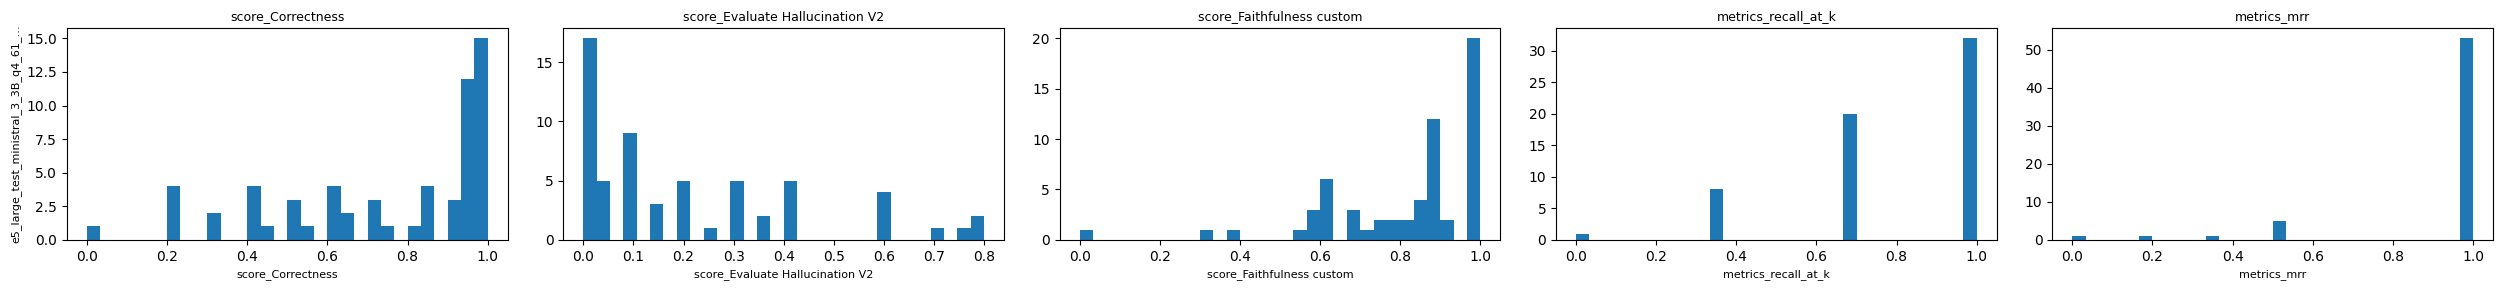

In [17]:
plot_generation_quality_as_hist(df_single)

---
# 2  Multiple Runs Analysis

Compare across different configurations (different `run_id` values). Load all files or a filtered subset below.

In [18]:
# Load multiple export files for comparison.
# Adjust the pattern to select the relevant set of runs.
df_multi = load_files(folder=EXPORT_DIR, pattern="*langfuse_export*.parquet")

run_ids = get_run_ids(df_multi)
print(f"\nRun IDs ({len(run_ids)}):")
for r in run_ids:
    print(f"  {r}")

Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q4_61_40085d87.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q4_61_79ef3626.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q5_61_23c47ab9.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q5_61_f096093a.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q8_61_2a62bc35.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_3B_q8_61_73db2260.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q4_61_5b437b29.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q4_61_e4176cee.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q5_61_907aac99.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_ministral_3_8B_q5_61_d4b17c70.parquet
Loading: 2026-03-10_14-11_langfuse_export_e5_large_test_mist

## 2.1  Mean Metrics per Run ID

In [19]:
multi_metric_cols = _numeric_metric_cols(df_multi)
df_multi.groupby("run_id")[multi_metric_cols].mean().round(3)

,latency_ms,latency_ttft_ms,latency_llm_generation_latency_ms,latency_prompt_ms,latency_predicted_ms,latency_predicted_per_token_ms,generation_prompt_tokens,generation_completion_tokens,generation_tokens_per_second,latency_retrieval_latency_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Faithfulness custom,score_Correctness,score_Evaluate Hallucination V2
run_id,,,,,,,,,,,,,,,,,,,,,
e5_large_test_ministral_3_3B_q4_61,5607.109,1092.190,4397.166,1071.325,4397.166,20.865,520.049,210.765,47.943,77.681,...,0.492,0.918,5601.277,7360.164,12.646,5.214383e+07,488923.628,0.837,0.739,0.213
e5_large_test_ministral_3_3B_q5_61,14010.044,2876.710,11035.115,2828.829,11035.115,47.881,520.049,208.902,38.221,73.225,...,0.492,0.918,6794.103,7768.522,13.905,8.294539e+07,923592.044,0.844,0.728,0.190
e5_large_test_ministral_3_3B_q8_61,6773.951,972.615,5658.448,946.065,5658.448,26.550,520.049,212.814,37.684,88.532,...,0.492,0.918,6763.990,8559.861,13.282,9.245393e+07,710958.164,0.831,0.743,0.197
e5_large_test_ministral_3_8B_q4_61,12798.803,2596.442,9974.663,2548.525,9974.663,47.917,520.049,205.016,22.072,98.719,...,0.492,0.918,12057.400,9637.039,15.056,1.740112e+08,1621389.290,0.863,0.773,0.167
e5_large_test_ministral_3_8B_q5_61,14139.169,2862.927,10979.420,2808.469,10979.420,54.458,520.049,201.240,18.366,103.022,...,0.492,0.918,14114.430,10236.741,15.350,3.436187e+08,2098494.951,0.876,0.758,0.165
e5_large_test_mistral_7B_0_3_iq3_61,8815.672,2684.792,5983.346,2646.899,5983.346,37.893,563.164,157.344,26.392,108.442,...,0.492,0.918,8807.553,8261.061,10.392,1.266824e+08,586332.328,0.844,0.616,0.290
e5_large_test_mistral_7B_0_3_q3l_61,9200.148,2798.768,6242.936,2751.802,6242.936,46.967,563.164,132.361,21.300,110.035,...,0.492,0.918,9186.665,8571.783,16.174,1.747155e+08,1311794.361,0.877,0.731,0.143
e5_large_test_mistral_7B_0_3_q4_61,7944.410,2565.724,5234.818,2527.244,5234.818,38.480,563.164,135.443,25.991,100.519,...,0.492,0.918,7934.461,8924.235,10.593,9.838968e+07,531002.754,0.923,0.714,0.128
e5_large_test_mistral_7B_0_3_q8_61,8857.689,2286.046,6196.911,2238.282,6196.911,47.764,563.164,129.443,20.946,119.937,...,0.492,0.918,8837.843,11201.693,16.916,2.994372e+08,775956.984,0.903,0.716,0.104


## 2.2  Boxplots by Run ID

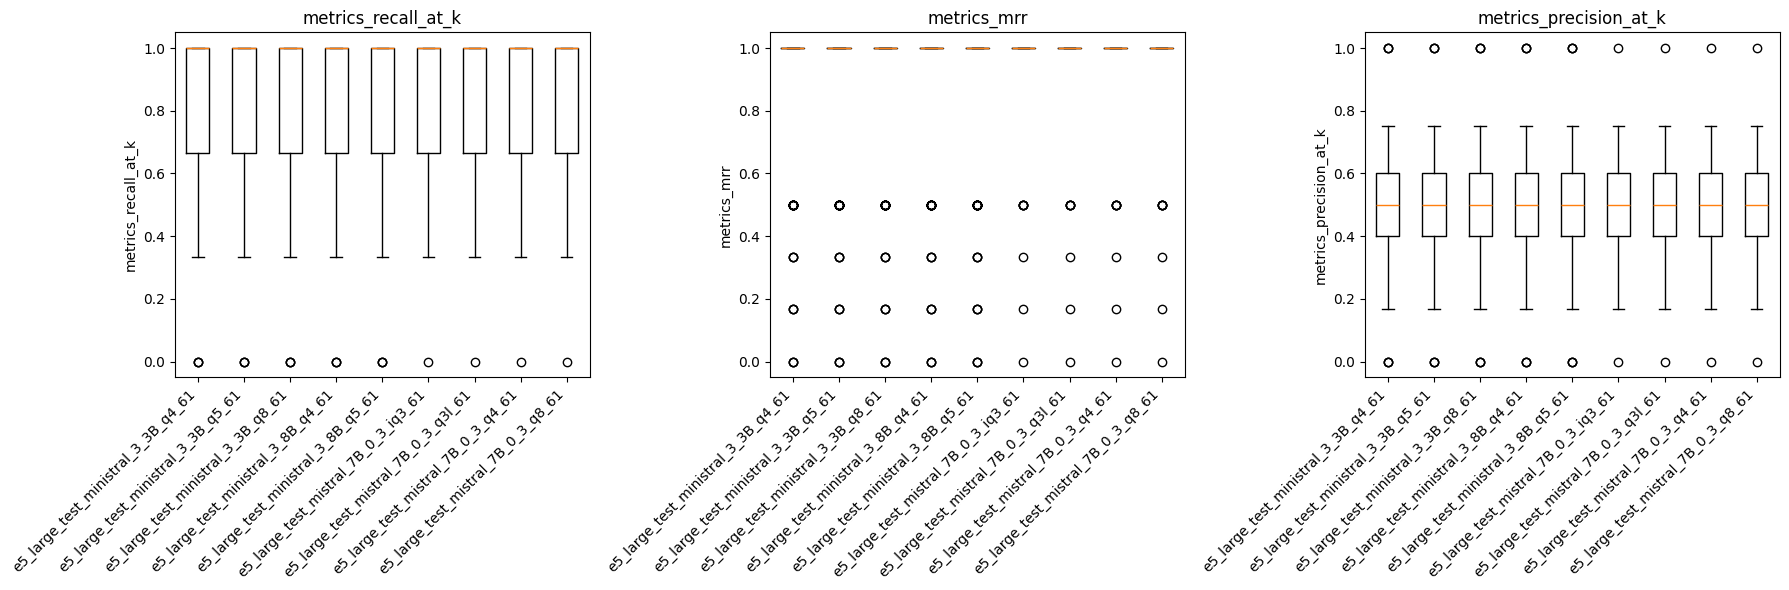

In [20]:
# Optional: set explicit order for run_ids on the x axis
run_order = None  # or: run_order = ["run_a", "run_b", ...]

plot_boxplots(df_multi, ["metrics_recall_at_k", "metrics_mrr", "metrics_precision_at_k"],
              group_by="run_id", group_order=run_order, figsize=(18, 6))

## 2.3  Histogram Grids by Run ID

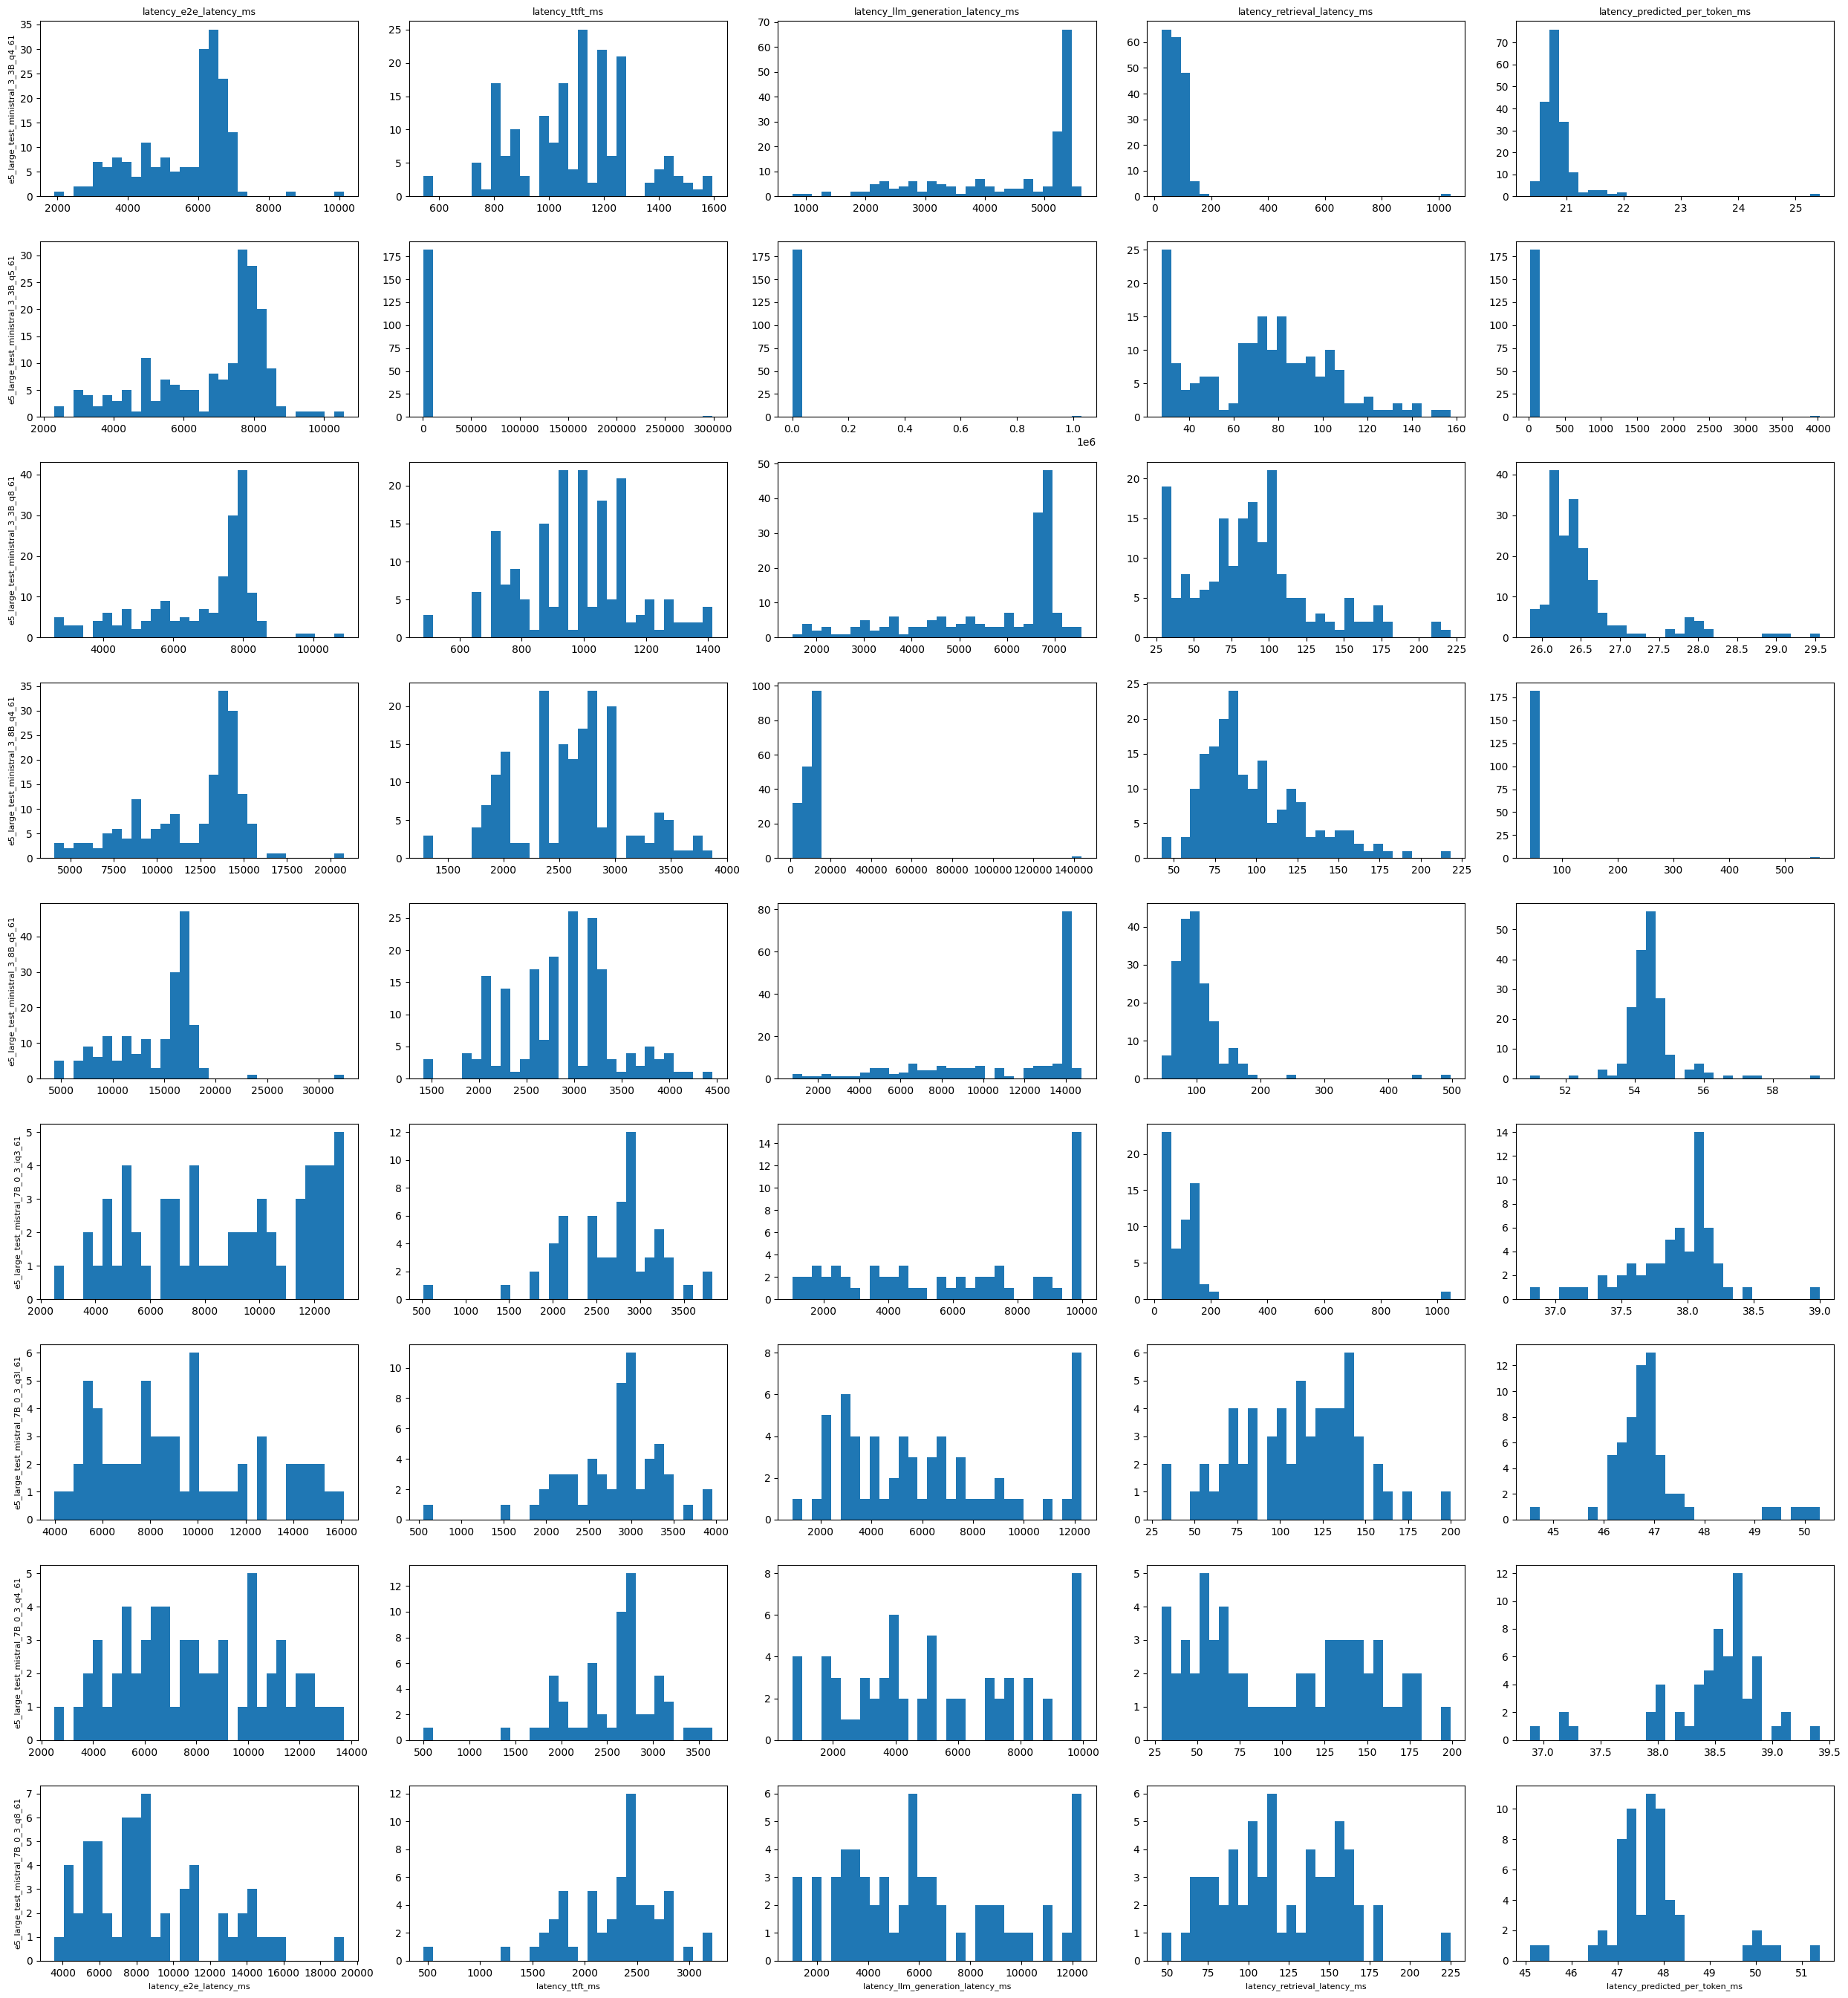

In [21]:
plot_latency_as_hist(df_multi, group_by="run_id", group_order=run_order)

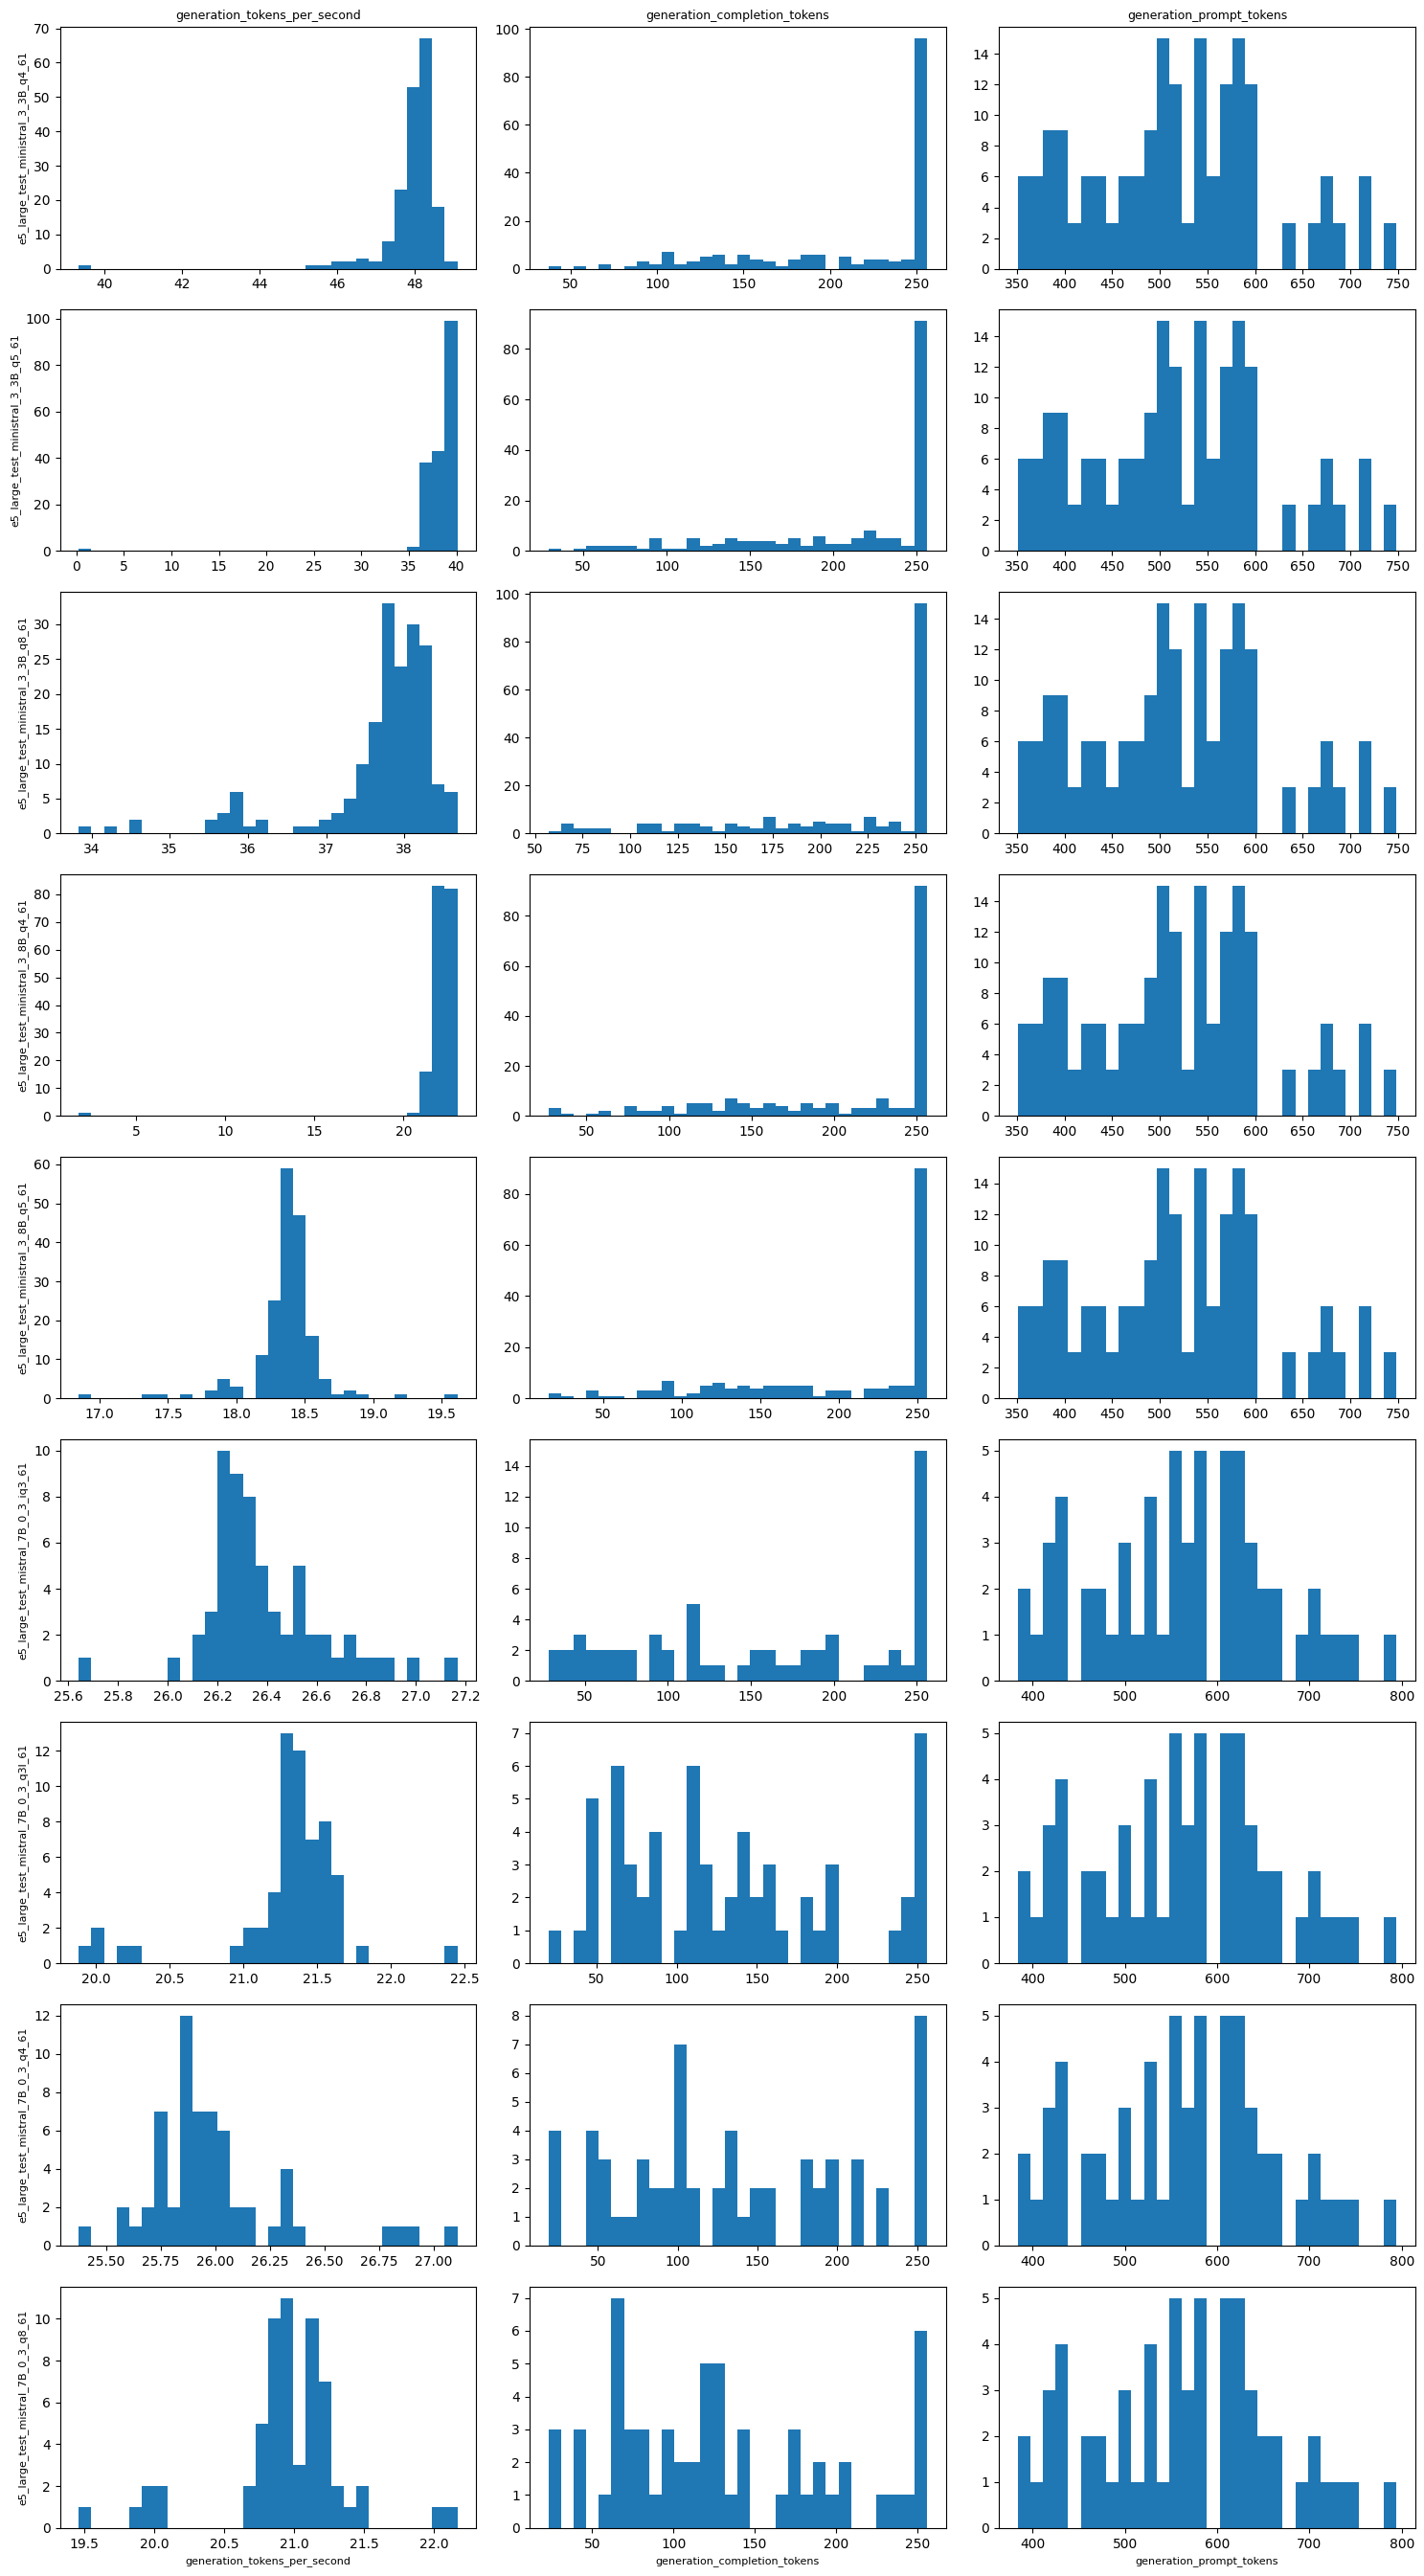

In [22]:
plot_generation_as_hist(df_multi, group_by="run_id", group_order=run_order)

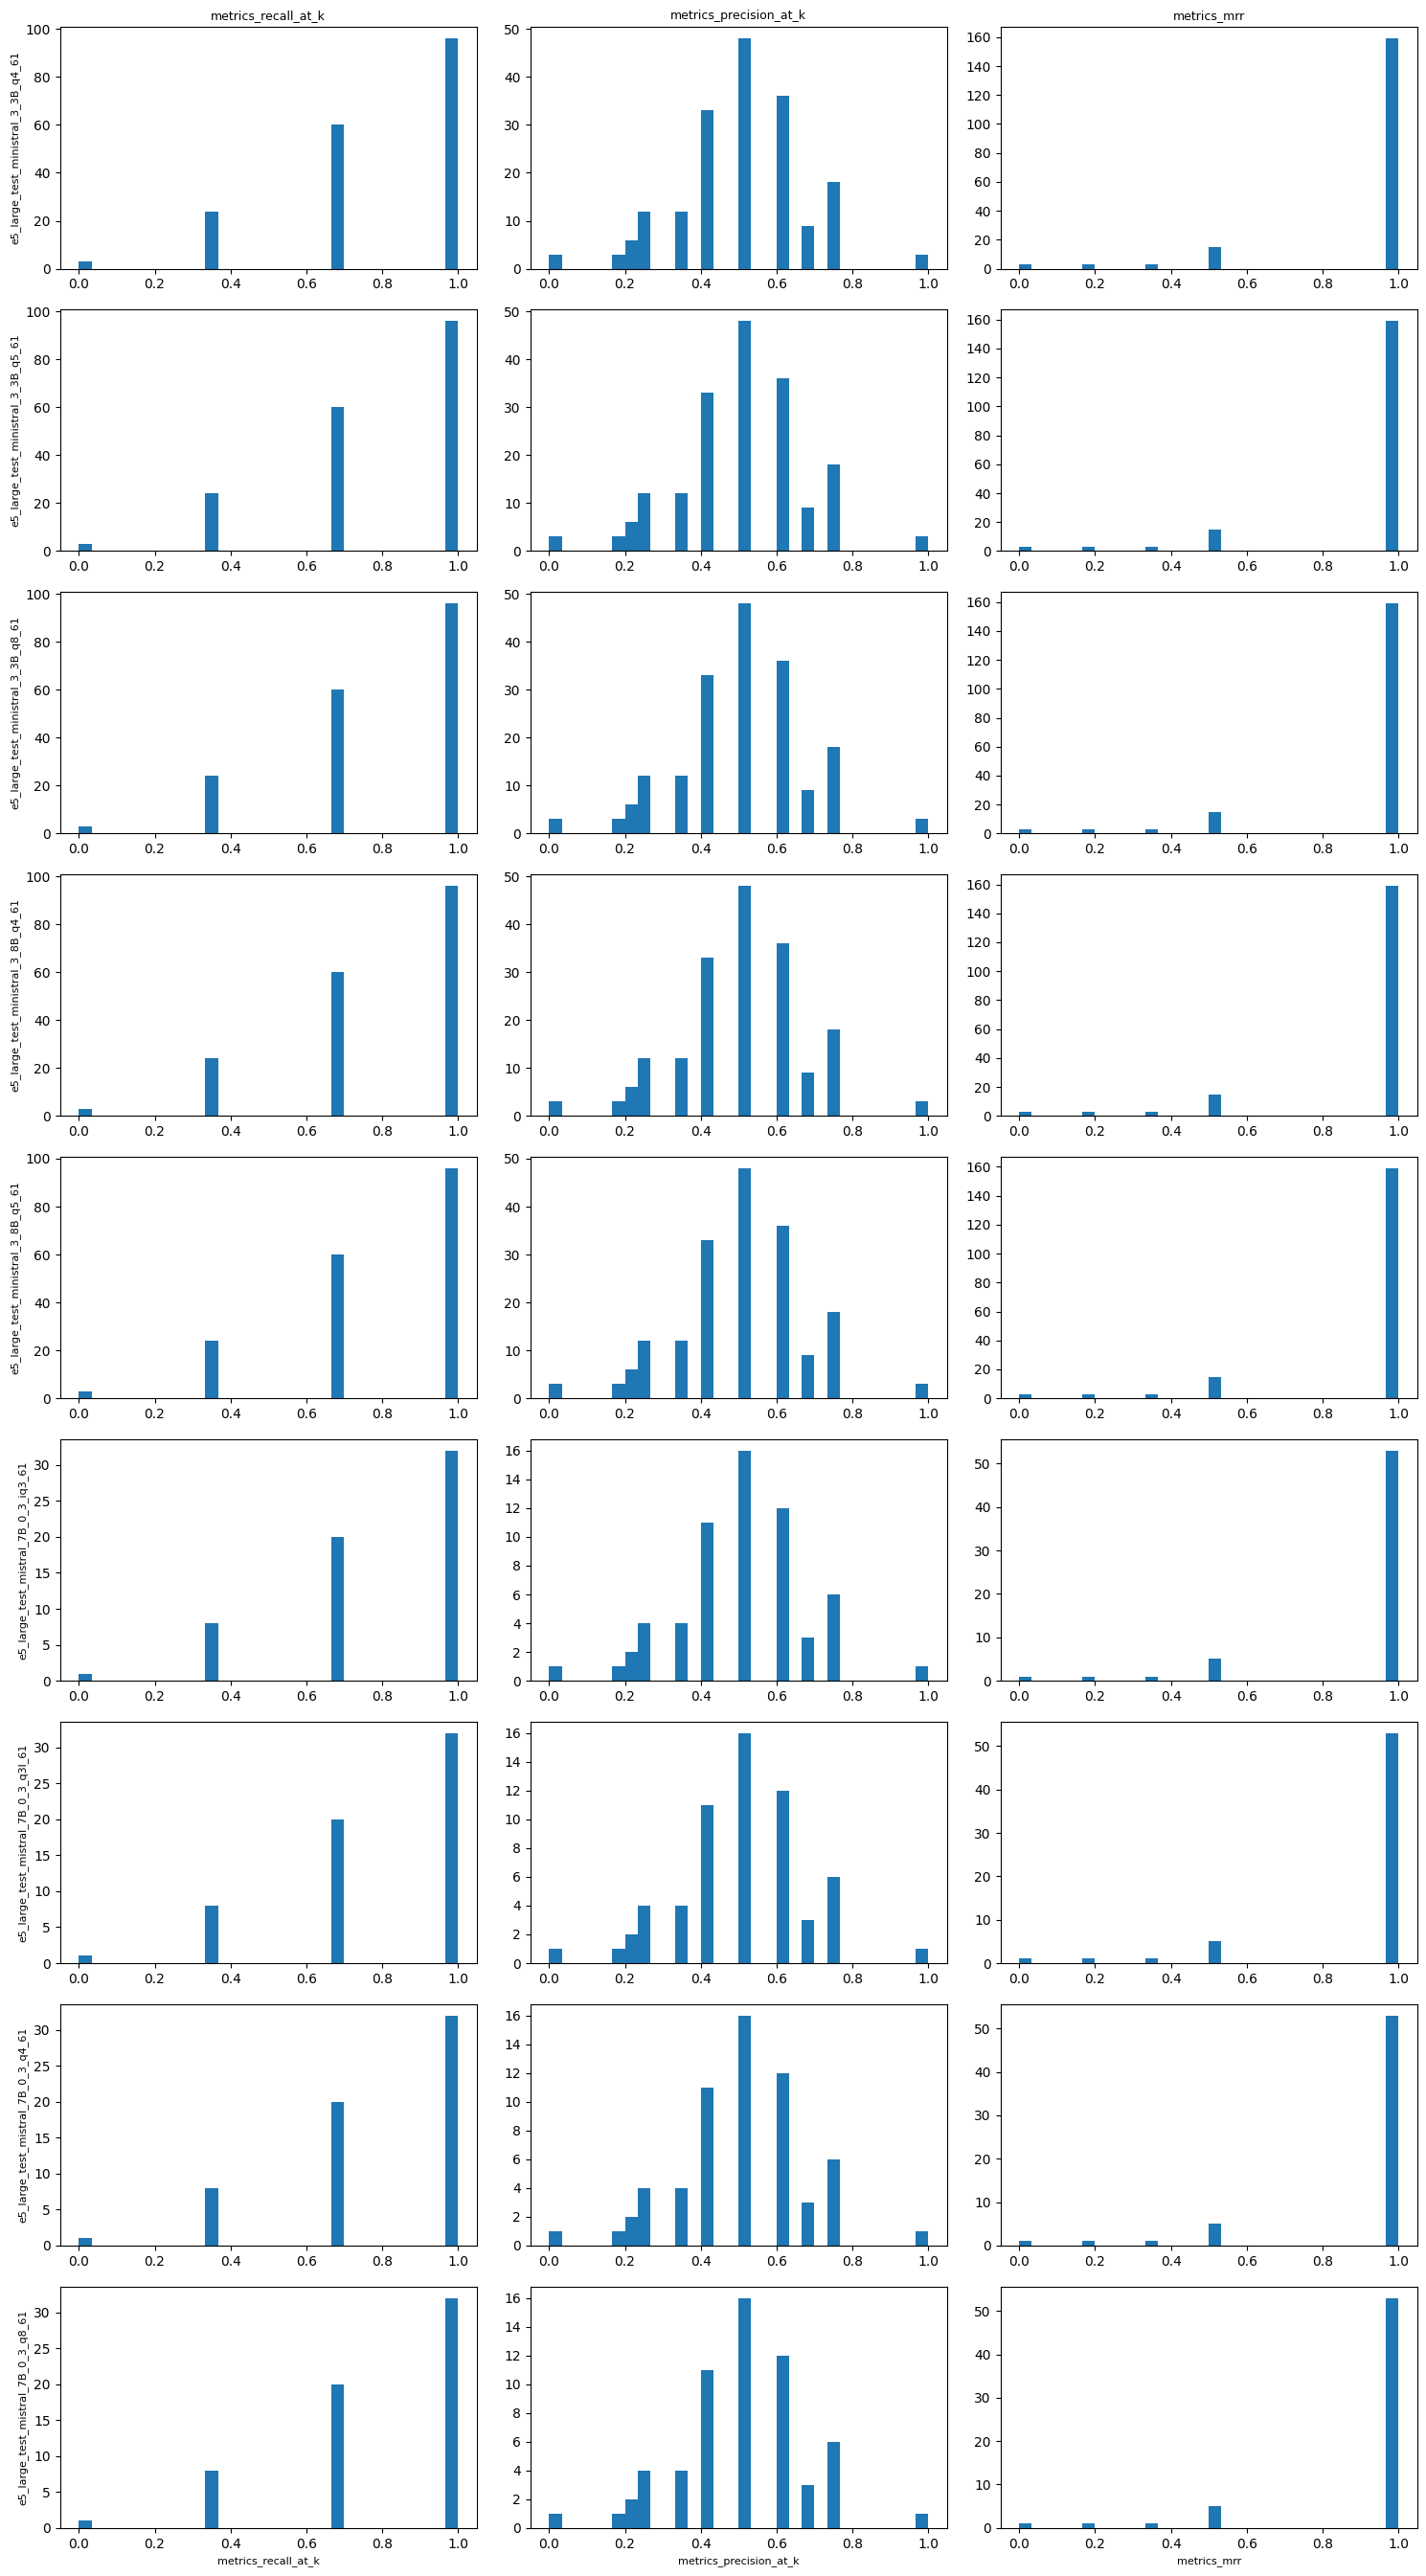

In [23]:
plot_retrieval_as_hist(df_multi, group_by="run_id", group_order=run_order)

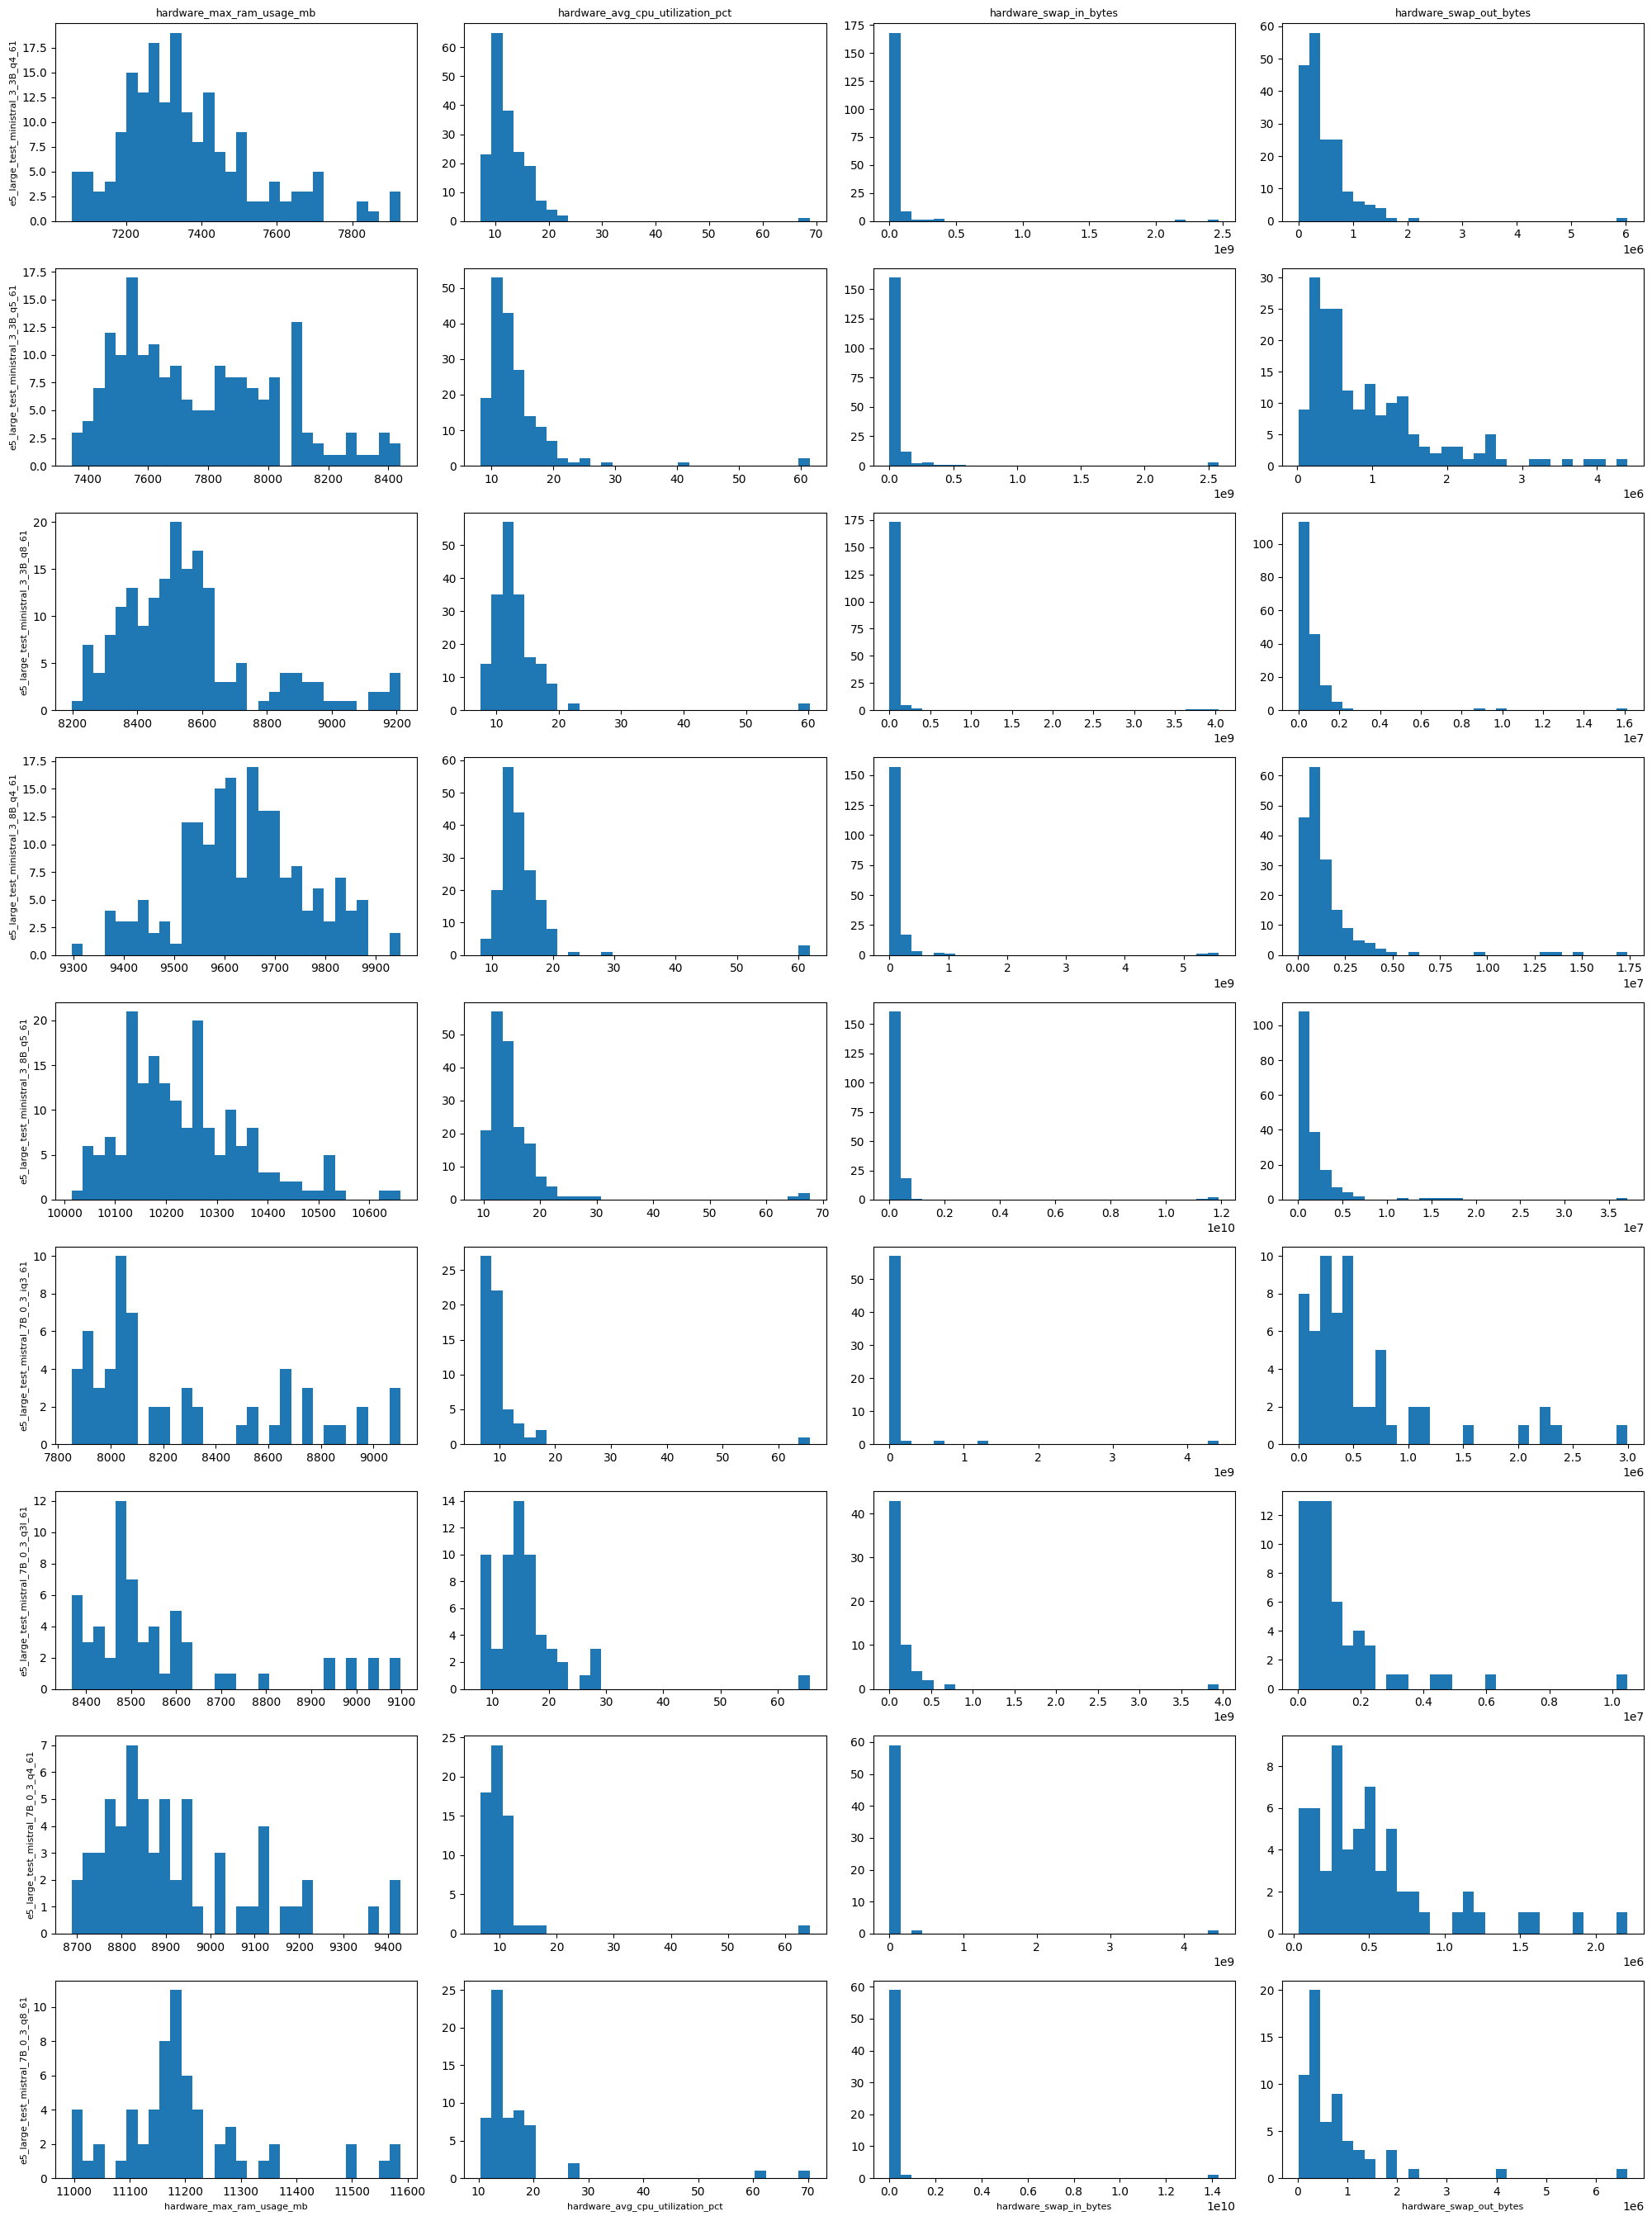

In [24]:
plot_hardware_as_hist(df_multi, group_by="run_id", group_order=run_order)

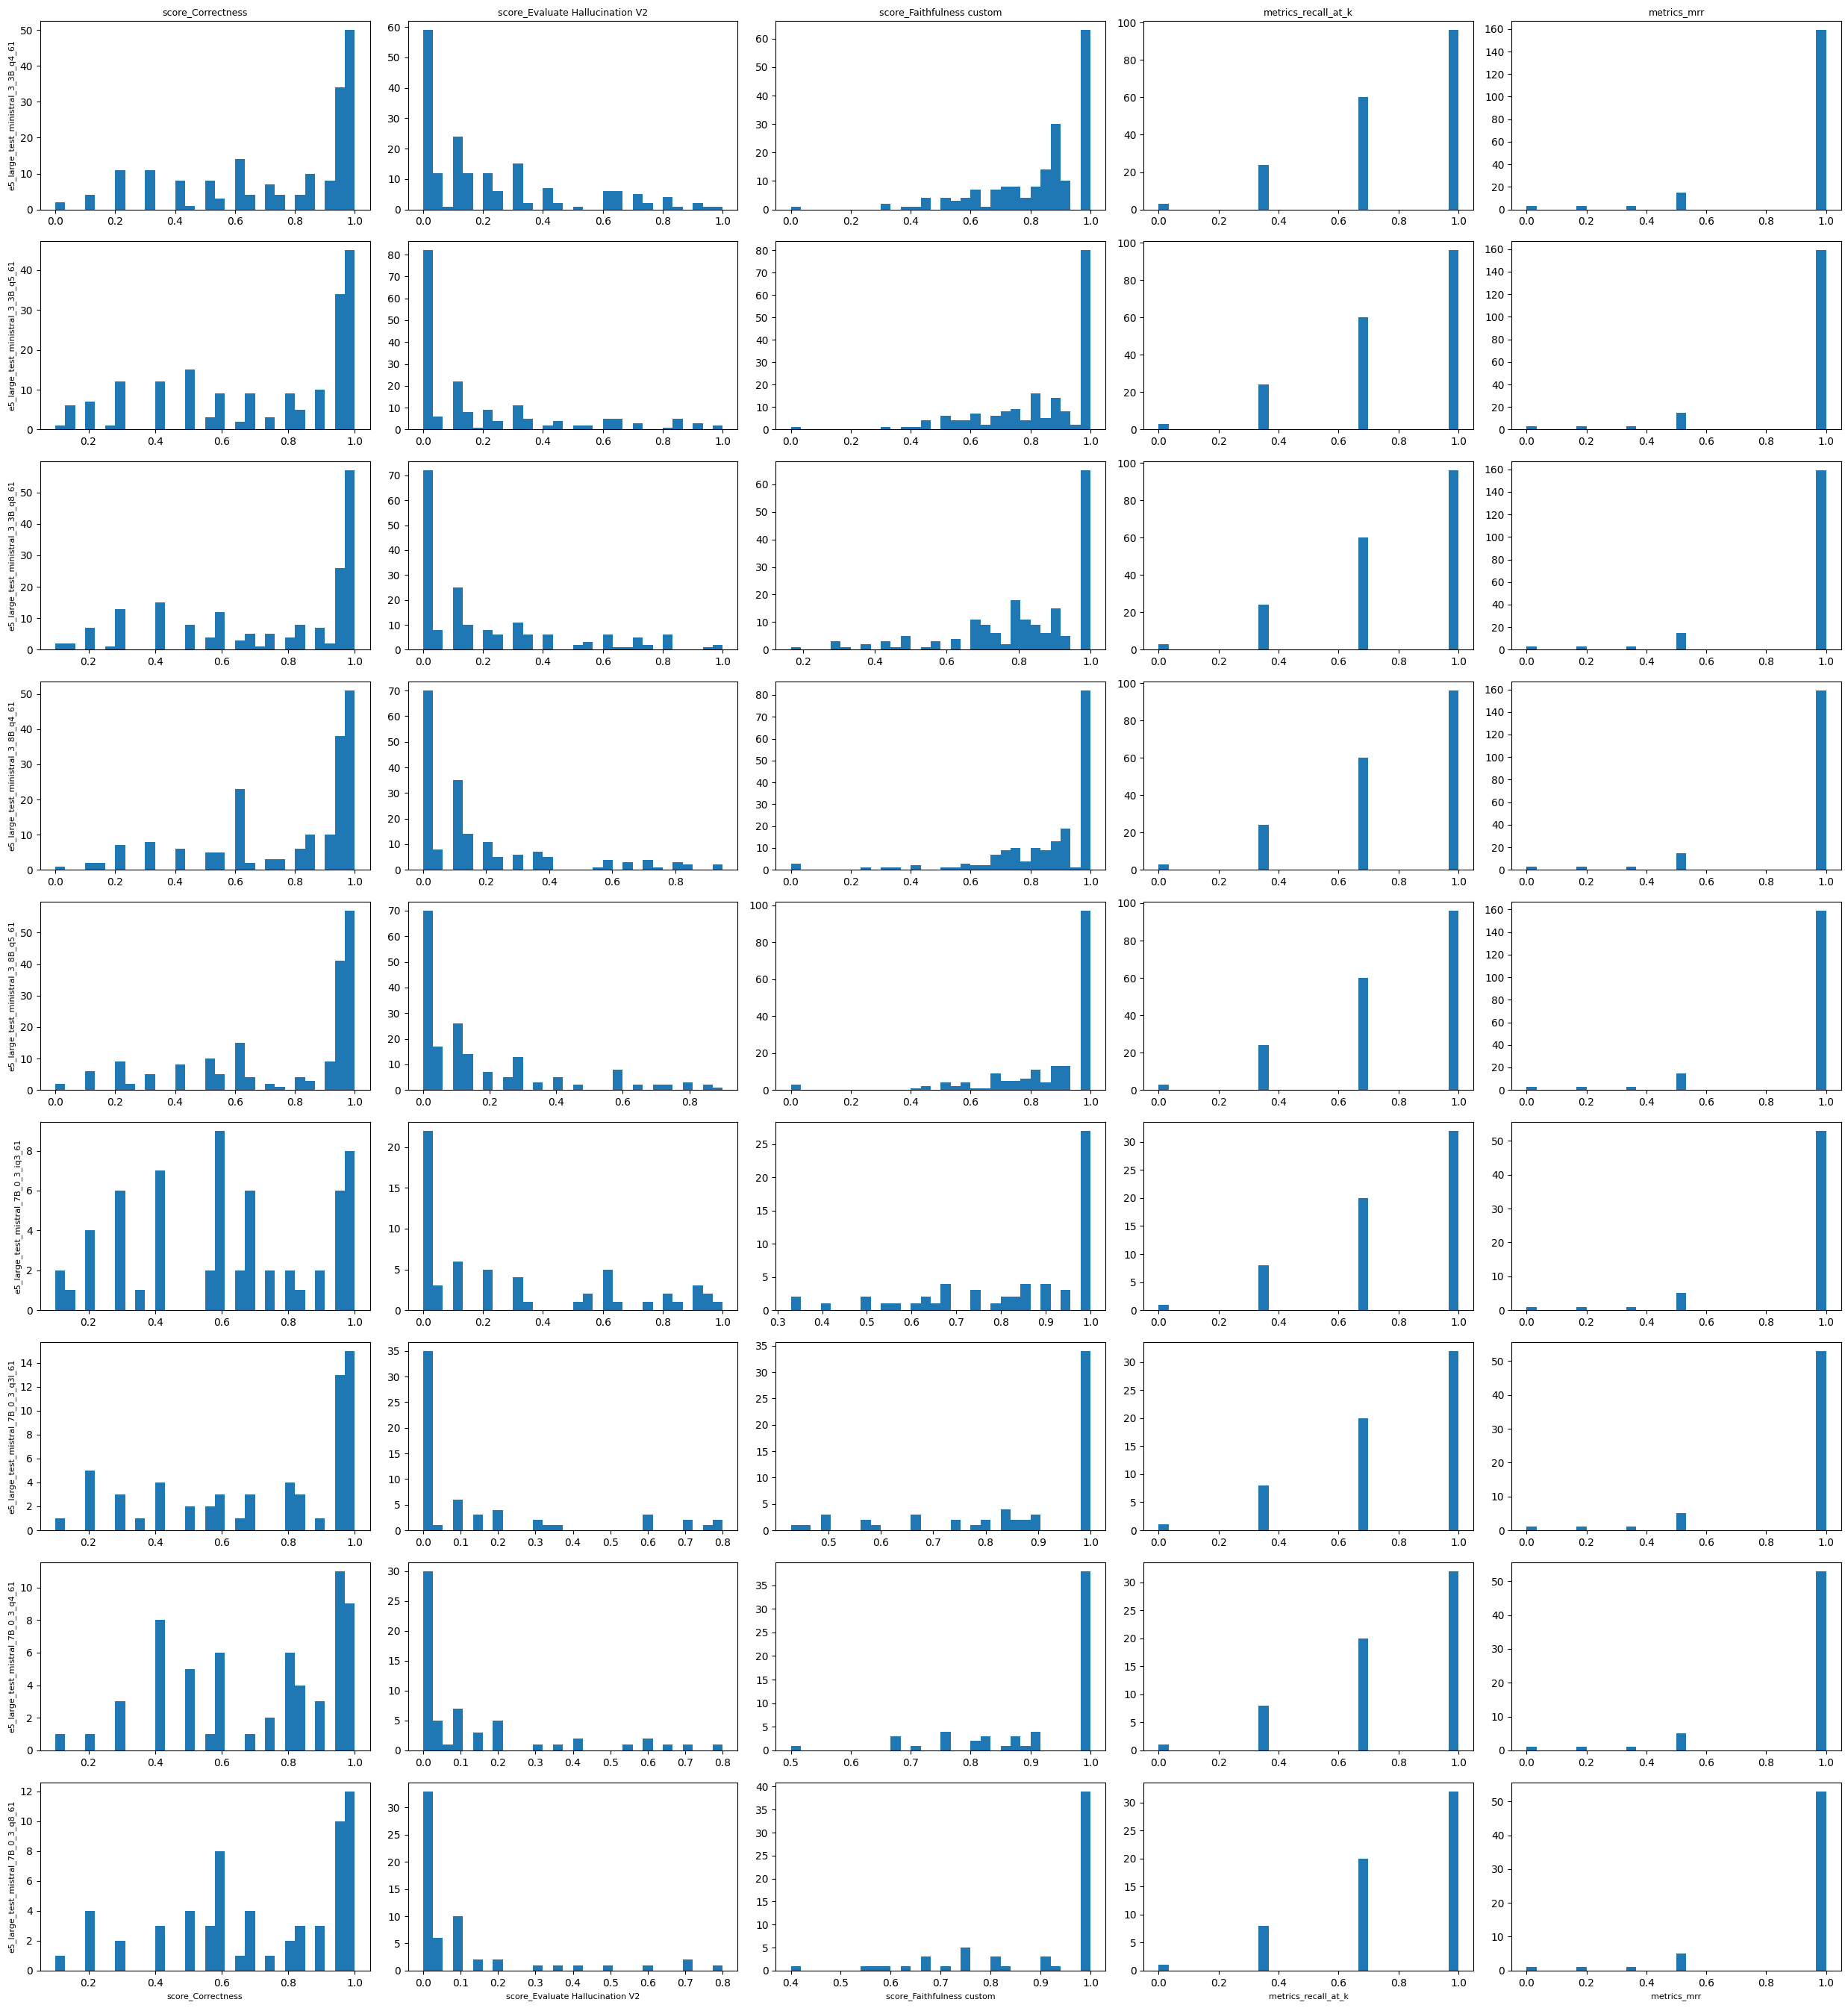

In [25]:
plot_generation_quality_as_hist(df_multi, group_by="run_id", group_order=run_order)

## 2.4  Scatter: Two Metrics by Run ID

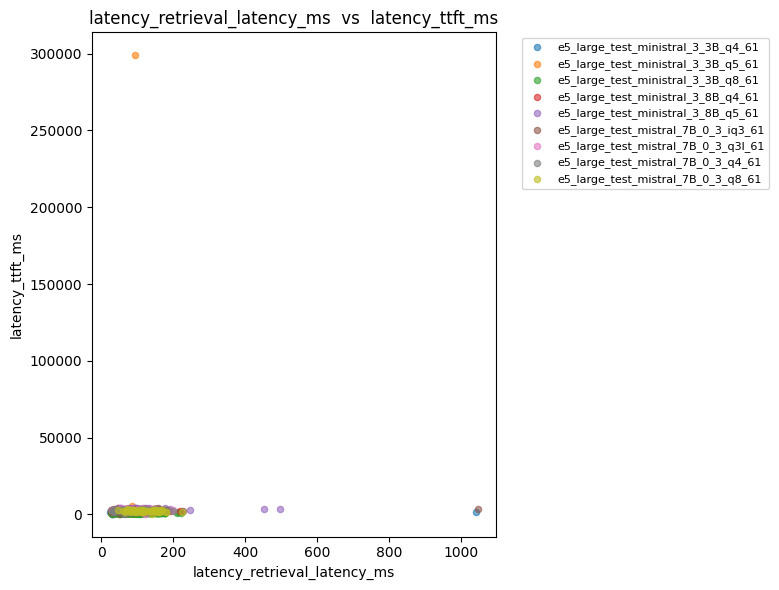

In [26]:
plot_scatter_two_metrics(
    df_multi, "latency_retrieval_latency_ms", "latency_ttft_ms",
    group_by="run_id", group_order=run_order,
)

---
# 3  Stability Analysis — Repeated Sessions of One Run ID

Multiple sessions (files) that share the same `run_id` let us assess run-to-run stability.
The `session_id` is the x-axis; one subplot per metric.

In [27]:
# Select the run_id to analyse for stability
STABILITY_RUN_ID = get_run_ids(df_multi)[0]  # replace with a string literal

df_stable = df_multi[df_multi["run_id"] == STABILITY_RUN_ID].copy()
stable_sessions = get_session_ids(df_stable)

print(f"Run ID:   {STABILITY_RUN_ID}")
print(f"Sessions ({len(stable_sessions)}):")
for s in stable_sessions:
    print(f"  {s}")

Run ID:   e5_large_test_ministral_3_3B_q4_61
Sessions (3):
  e5_large_test_ministral_3_3B_q4_61_40085d87
  e5_large_test_ministral_3_3B_q4_61_467677c6
  e5_large_test_ministral_3_3B_q4_61_79ef3626


## 3.1  Boxplots — Session ID as x-axis

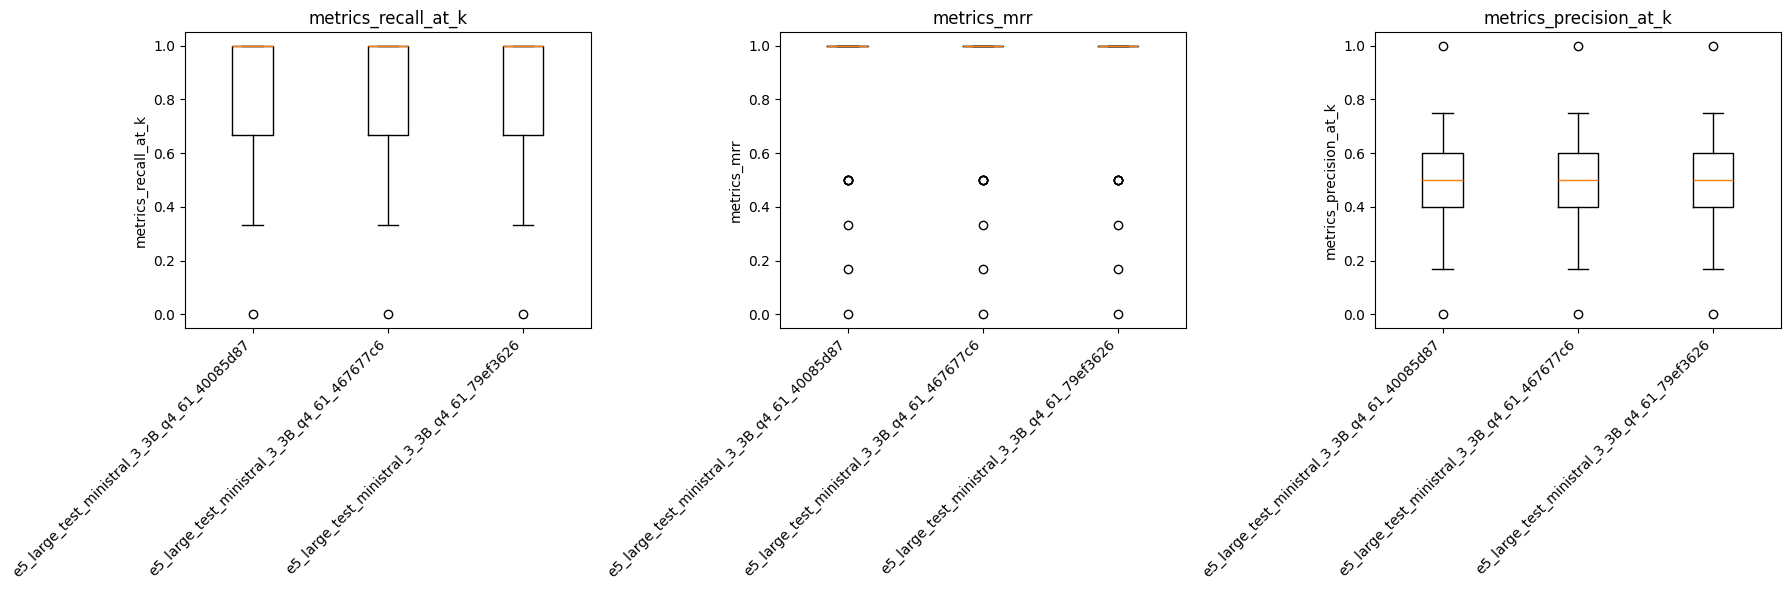

In [28]:
plot_boxplots(df_stable, ["metrics_recall_at_k", "metrics_mrr", "metrics_precision_at_k"],
              group_by="session_id", group_order=stable_sessions, figsize=(18, 6))

## 3.2  Histogram Grids — Sessions as rows

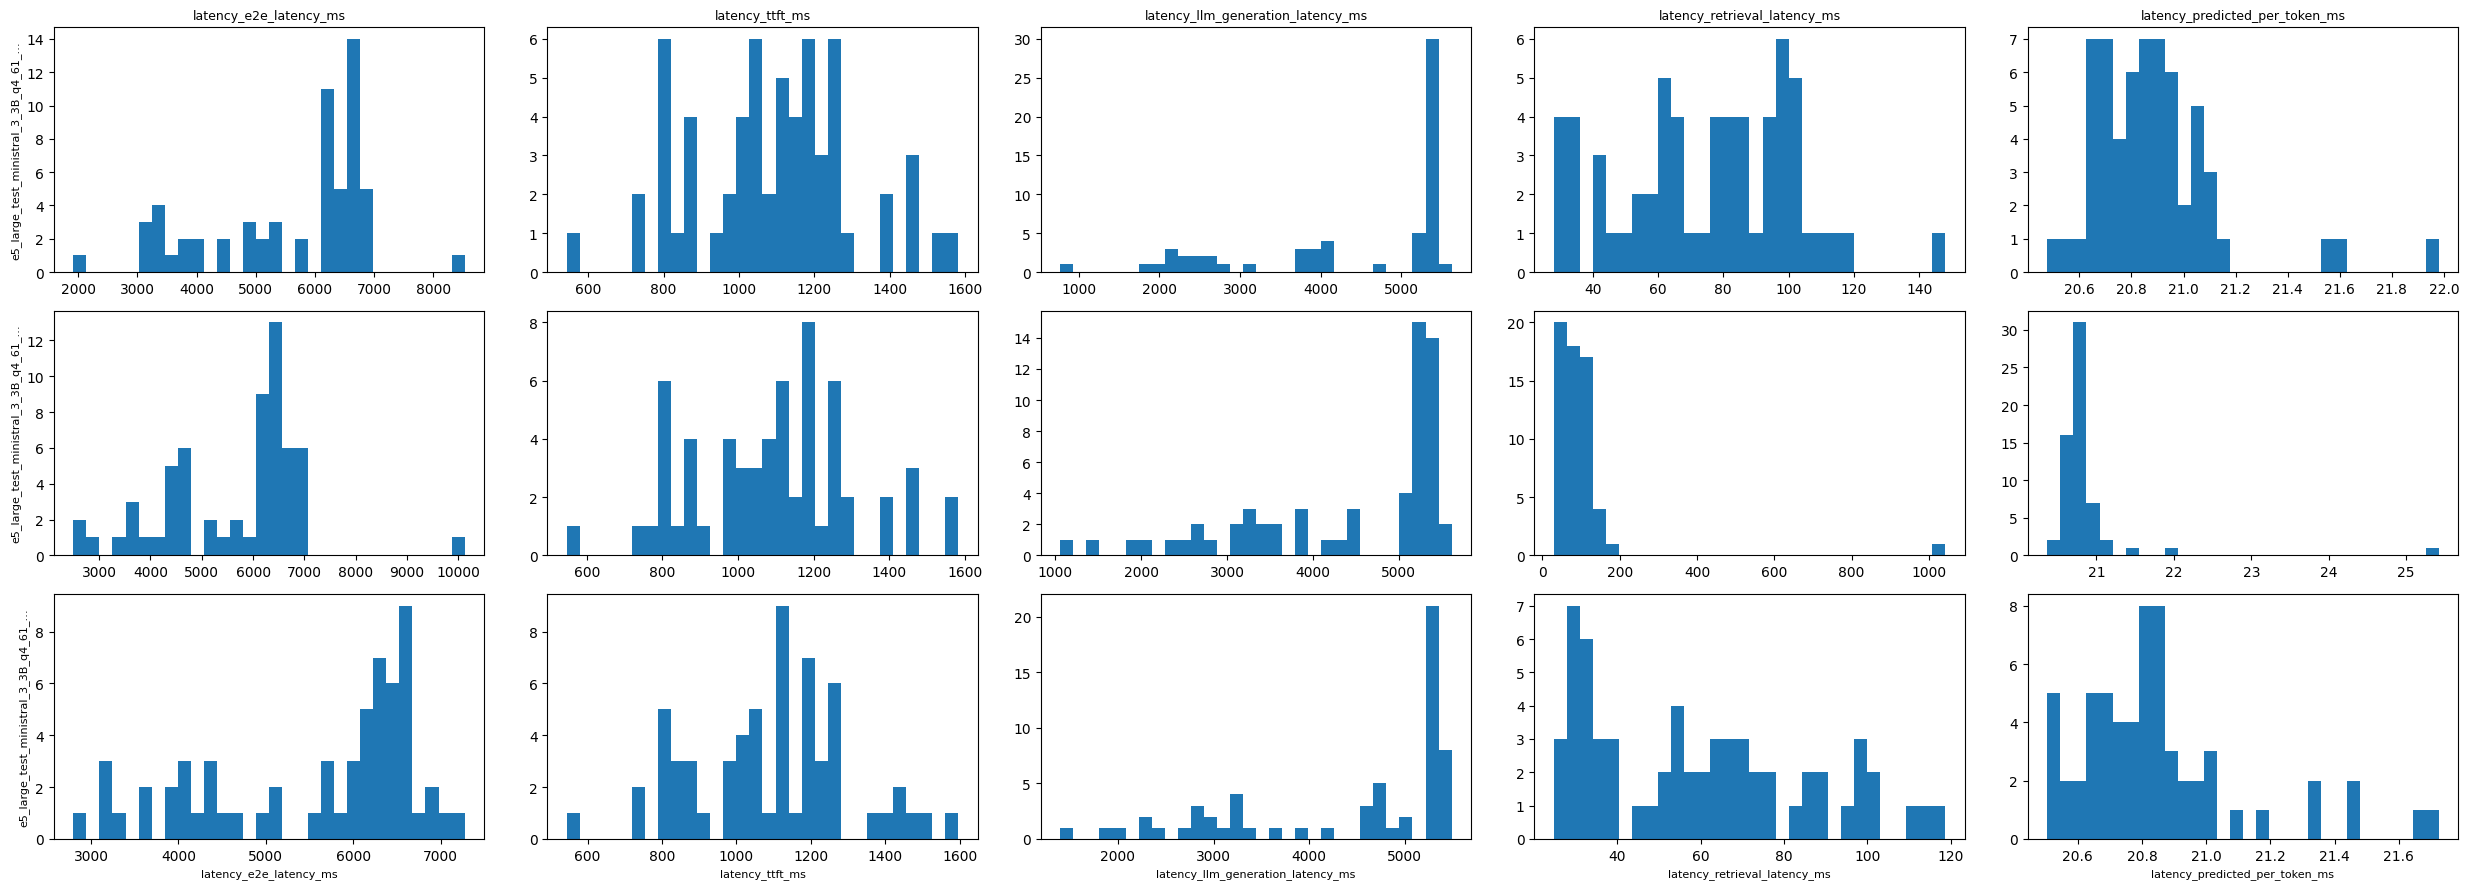

In [29]:
plot_latency_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

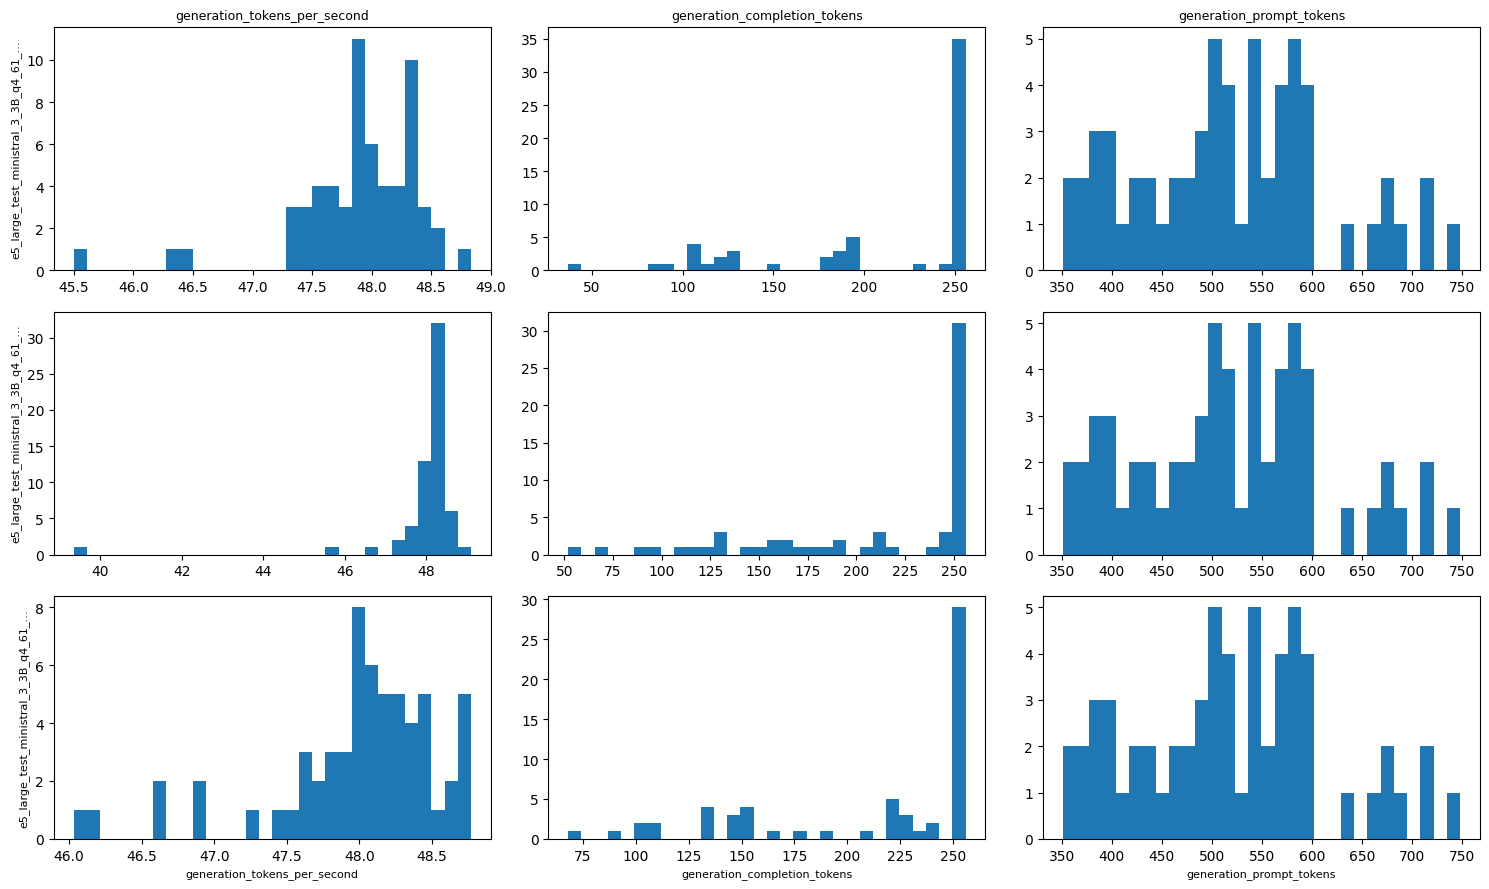

In [30]:
plot_generation_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

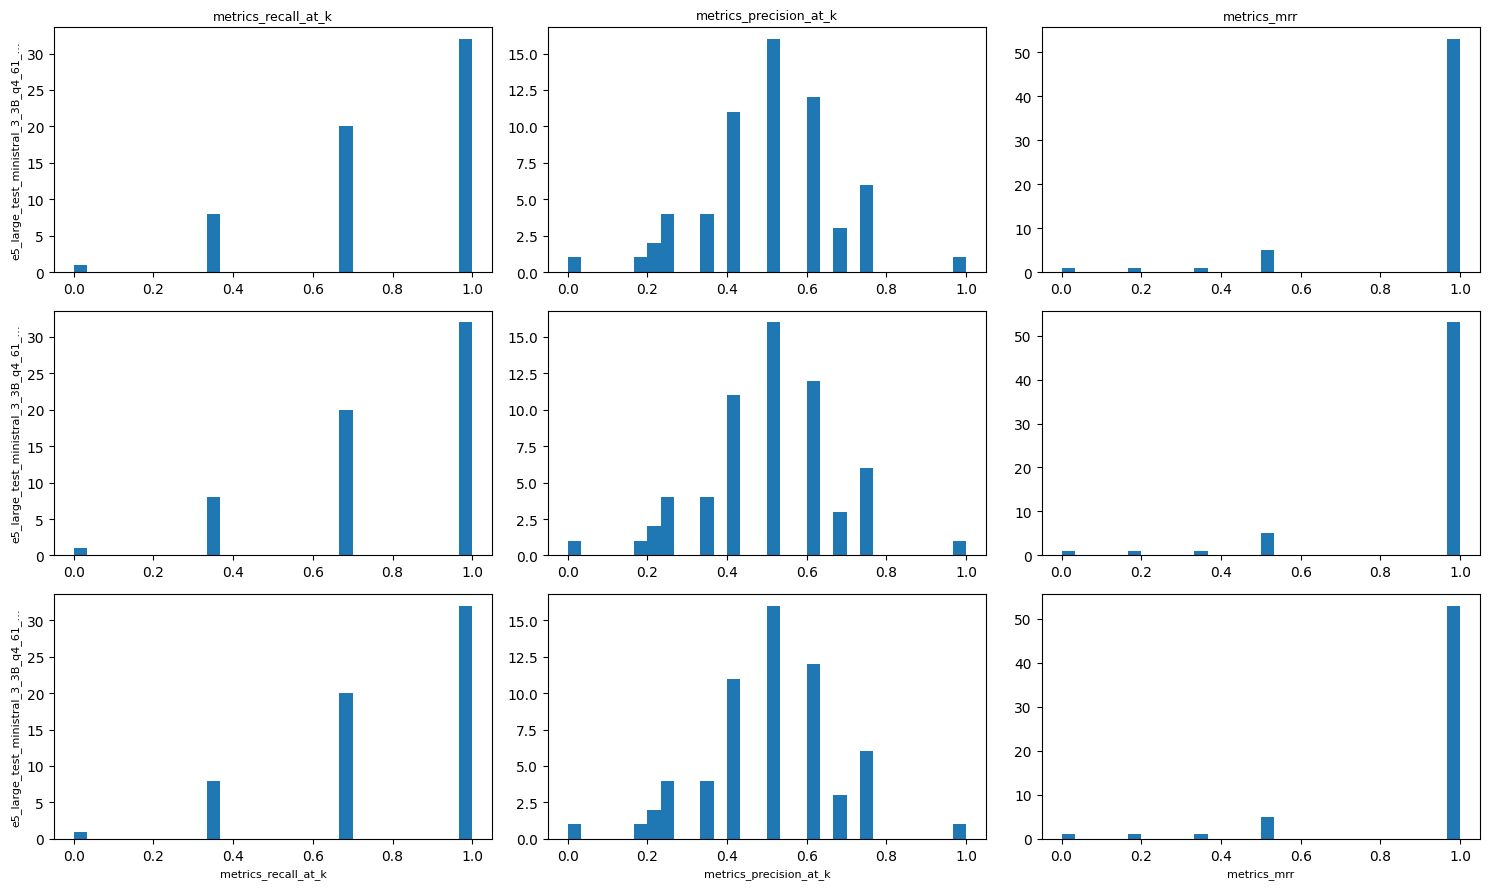

In [31]:
plot_retrieval_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

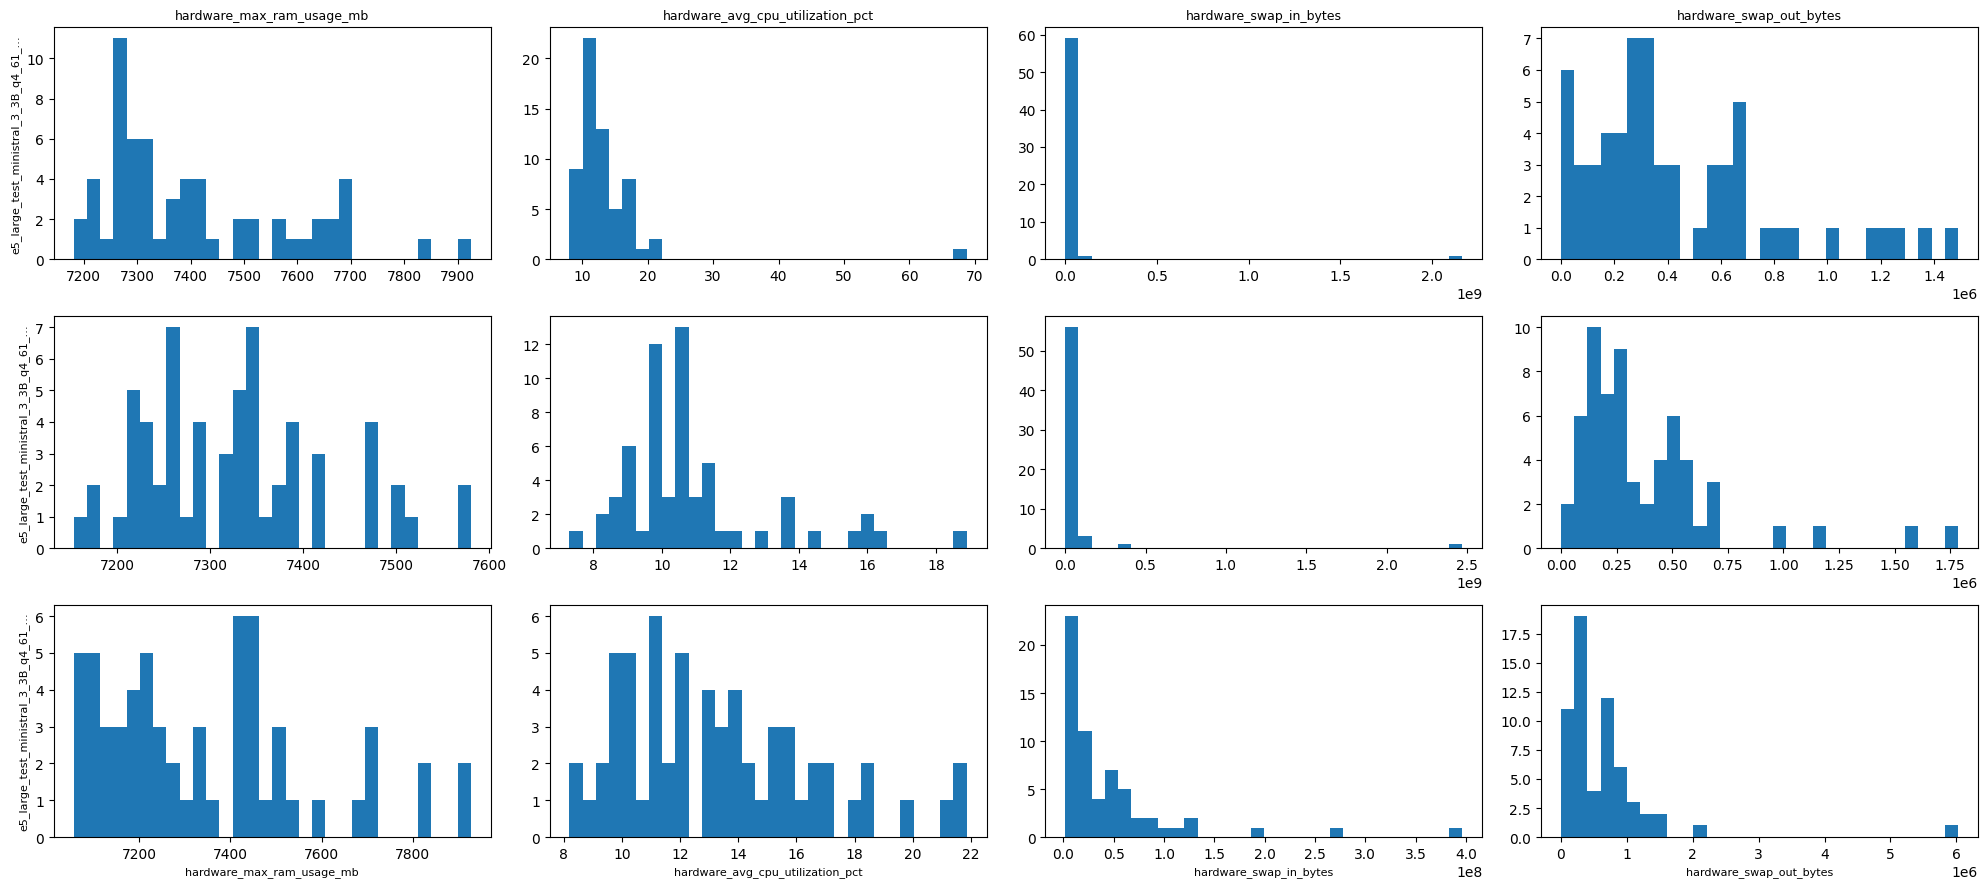

In [32]:
plot_hardware_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

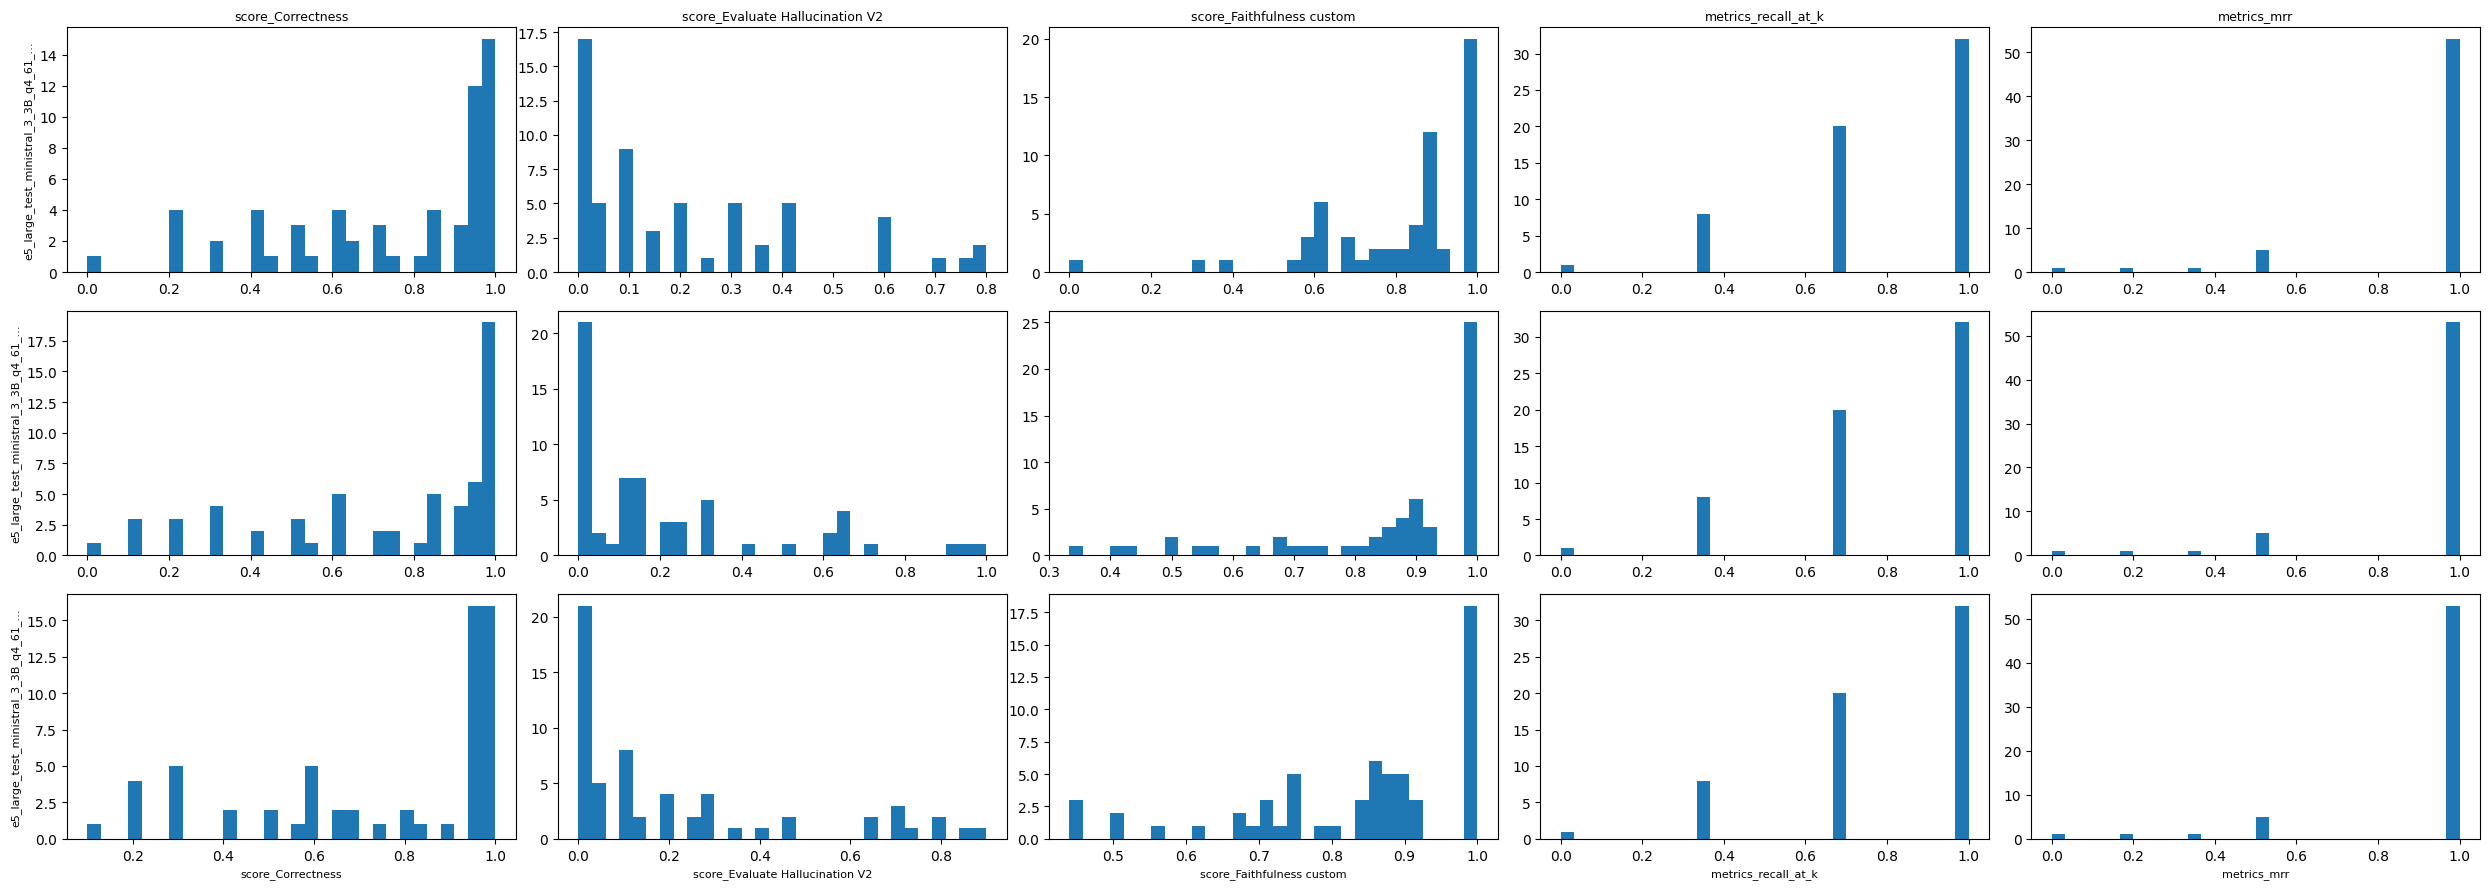

In [33]:
plot_generation_quality_as_hist(df_stable, group_by="session_id", group_order=stable_sessions)

## 3.3  Stats Across Sessions — Line & Multi-line

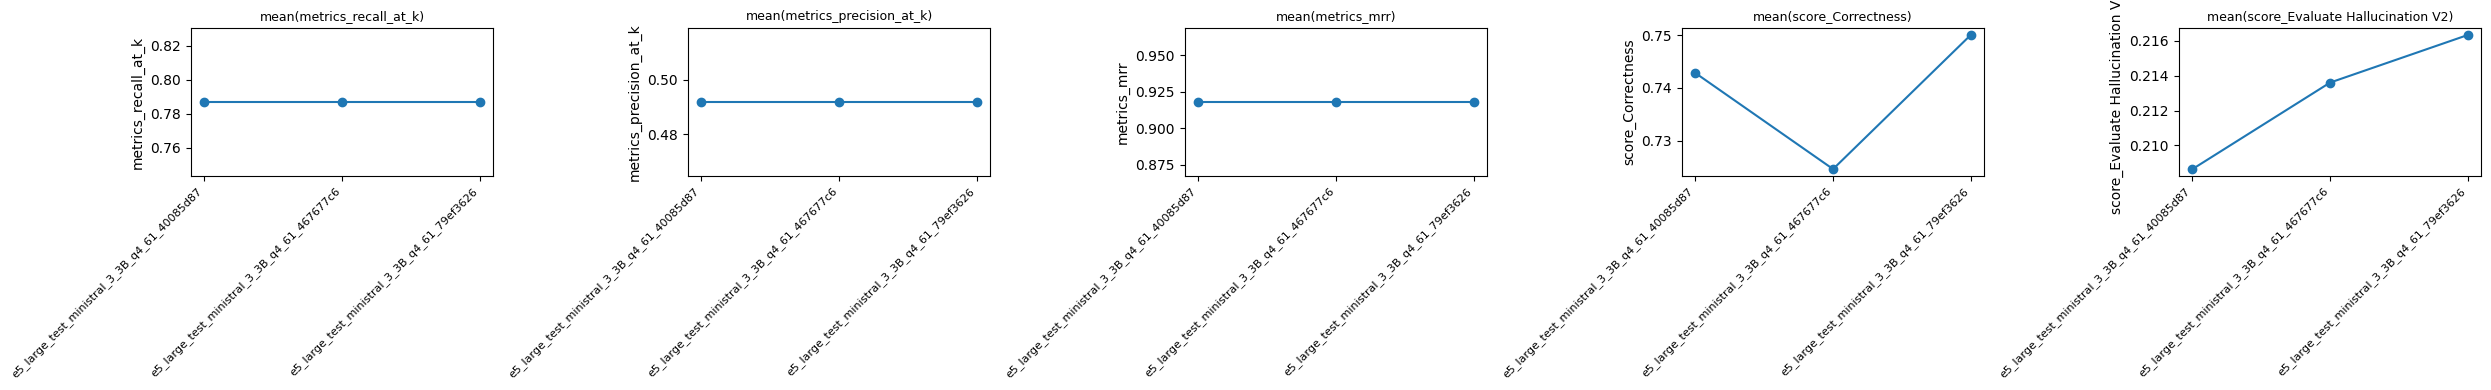

In [34]:
# Mean of each metric across sessions — one subplot per metric
plot_stats_line(df_stable, _present(df_stable, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
                group_by="session_id", group_order=stable_sessions, stat="mean")

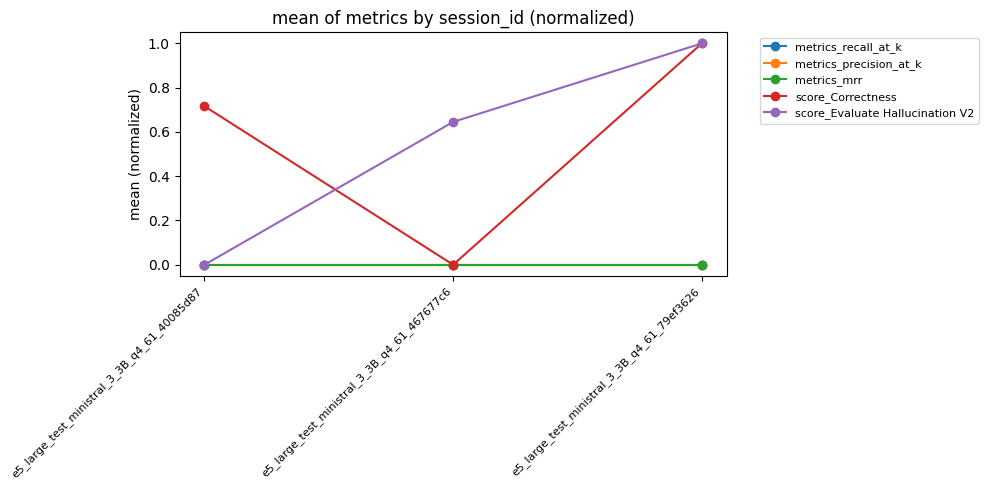

In [35]:
# All quality metrics overlaid in one plot (normalized so different scales are comparable)
plot_stats_multi_line(
    df_stable,
    _present(df_stable, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
    group_by="session_id", group_order=stable_sessions,
    stat="mean", normalize=True,
)

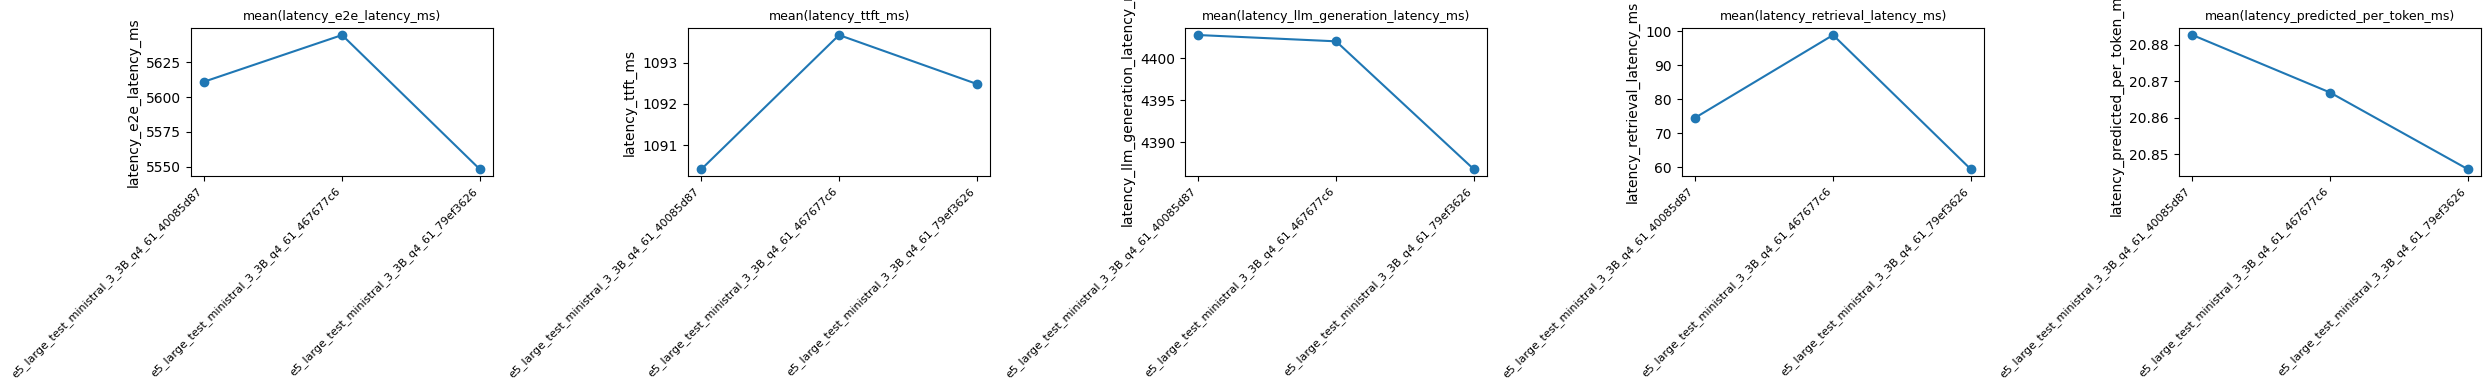

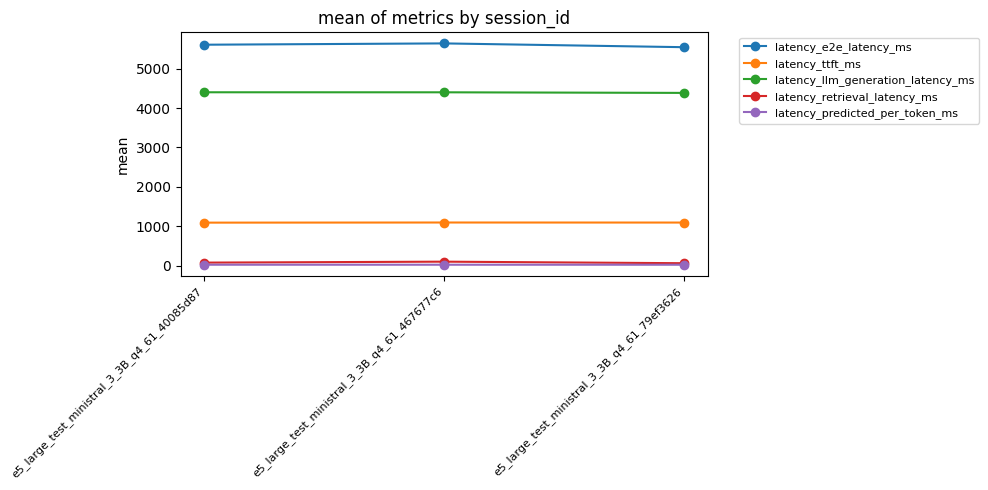

In [37]:
# Latency stability across sessions
plot_stats_line(df_stable, _present(df_stable, LATENCY_COLS),
                group_by="session_id", group_order=stable_sessions, stat="mean")
plot_stats_multi_line(df_stable, _present(df_stable, LATENCY_COLS),
                      group_by="session_id", group_order=stable_sessions,
                      stat="mean", normalize=False)

---
# 4  Per-Session Statistics for a Given Run ID

Descriptive stats (mean, std, median, etc.) broken down by `session_id` within one `run_id`.

In [39]:
# Select the run_id for per-session statistics (can be same as STABILITY_RUN_ID or different)
STATS_RUN_ID = get_run_ids(df_multi)[0]  # replace with a string literal
STATS_RUN_ID = "e5_large_test_ministral_3_8B_q4_61"

df_stats = df_multi[df_multi["run_id"] == STATS_RUN_ID].copy()
stats_sessions = get_session_ids(df_stats)

print(f"Run ID: {STATS_RUN_ID}  |  {len(stats_sessions)} session(s)")

Run ID: e5_large_test_ministral_3_8B_q4_61  |  3 session(s)


## 4.1  Descriptive Statistics Table

In [55]:
display(stats_by_group(df_stats, group_by="session_id"))

latency_ms                        \
                                                 count       mean        std   
session_id                                                                     
e5_large_test_ministral_3_8B_q4_61_5b437b29       61.0  11892.951   2979.902   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad       61.0  14128.180  17528.349   
e5_large_test_ministral_3_8B_q4_61_e4176cee       61.0  12375.279   3226.265   

                                                                       \
                                                min      25%      50%   
session_id                                                              
e5_large_test_ministral_3_8B_q4_61_5b437b29  4093.0   9510.0  13375.0   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad  4951.0   9909.0  13325.0   
e5_large_test_ministral_3_8B_q4_61_e4176cee  4317.0  10256.0  13647.0   

                                                                \
                                                 75%       max   
session_id                                                       
e5_large_test_ministral_3_8B_q4_61_5b437b29  14014.0   16384.0   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad  14253.0  146885.0   
e5_large_test_ministral_3_8B_q4_61_e4176cee  14445.0   20838.0   

                                            latency_ttft_ms            ...  \
                                                      count      mean  ...   
session_id                                                             ...   
e5_large_test_ministral_3_8B_q4_61_5b437b29            61.0  2577.487  ...   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad            61.0  2594.710  ...   
e5_large_test_ministral_3_8B_q4_61_e4176cee            61.0  2617.130  ...   

                                            score_Correctness       \
                                                          75%  max   
session_id                                                           
e5_large_test_ministral_3_8B_q4_61_5b437b29              1.00  1.0   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad              1.00  1.0   
e5_large_test_ministral_3_8B_q4_61_e4176cee              0.95  1.0   

                                            score_Evaluate Hallucination V2  \
                                                                      count   
session_id                                                                    
e5_large_test_ministral_3_8B_q4_61_5b437b29                            61.0   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad                            59.0   
e5_large_test_ministral_3_8B_q4_61_e4176cee                            61.0   

                                                                          \
                                              mean    std  min  25%  50%   
session_id                                                                 
e5_large_test_ministral_3_8B_q4_61_5b437b29  0.154  0.212  0.0  0.0  0.1   
e5_large_test_ministral_3_8B_q4_61_6c1db0ad  0.191  0.235  0.0  0.0  0.1   
e5_large_test_ministral_3_8B_q4_61_e4176cee  0.156  0.237  0.0  0.0  0.1   

                                                         
                                              75%   max  
session_id                                               
e5_large_test_ministral_3_8B_q4_61_5b437b29  0.20  0.95  
e5_large_test_ministral_3_8B_q4_61_6c1db0ad  0.30  0.80  
e5_large_test_ministral_3_8B_q4_61_e4176cee  0.15  0.95  

[3 rows x 168 columns]

## 4.2  Mean per Session — Bar Charts

In [ ]:
plot_stats_bar(df_stats, _present(df_stats, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
               group_by="session_id", group_order=stats_sessions, stat="mean")

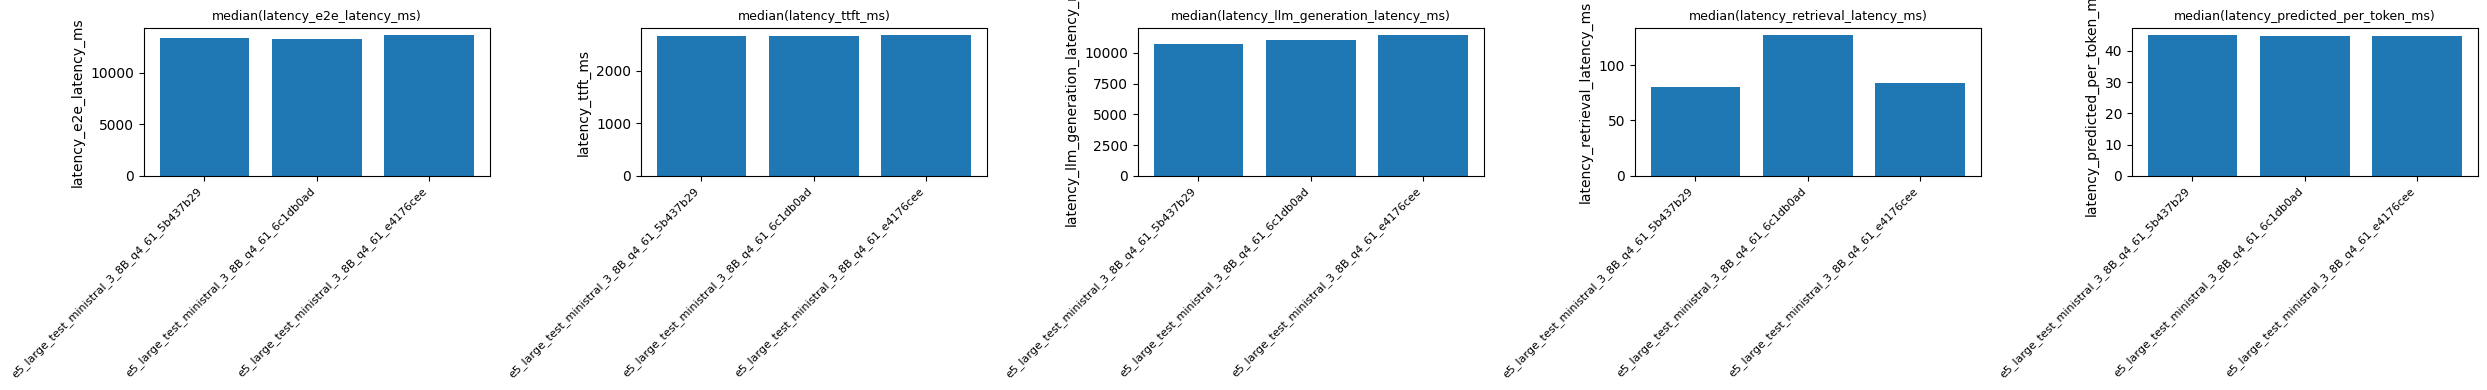

In [60]:
plot_stats_bar(df_stats, _present(df_stats, LATENCY_COLS),
               group_by="session_id", group_order=stats_sessions, stat="median")

## 4.3  Std per Session — Bar Charts (variance across runs)

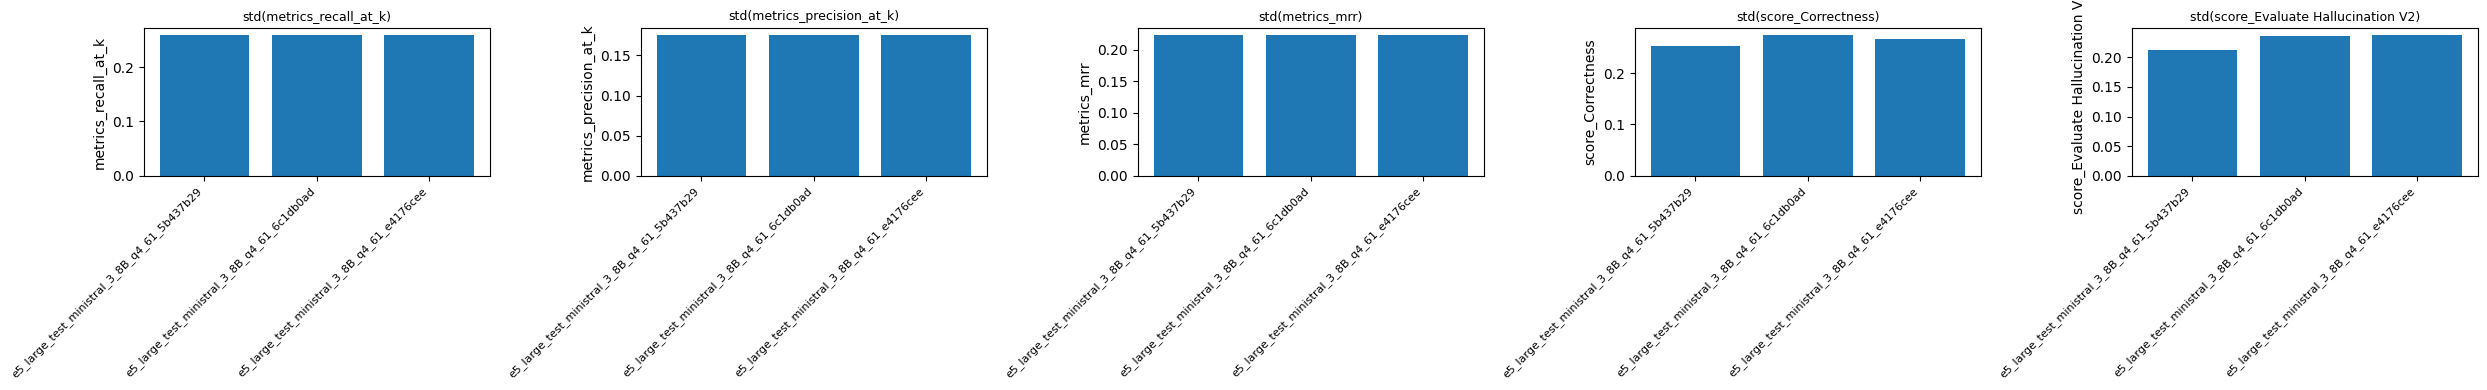

In [40]:
plot_stats_bar(df_stats, _present(df_stats, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
               group_by="session_id", group_order=stats_sessions, stat="std")

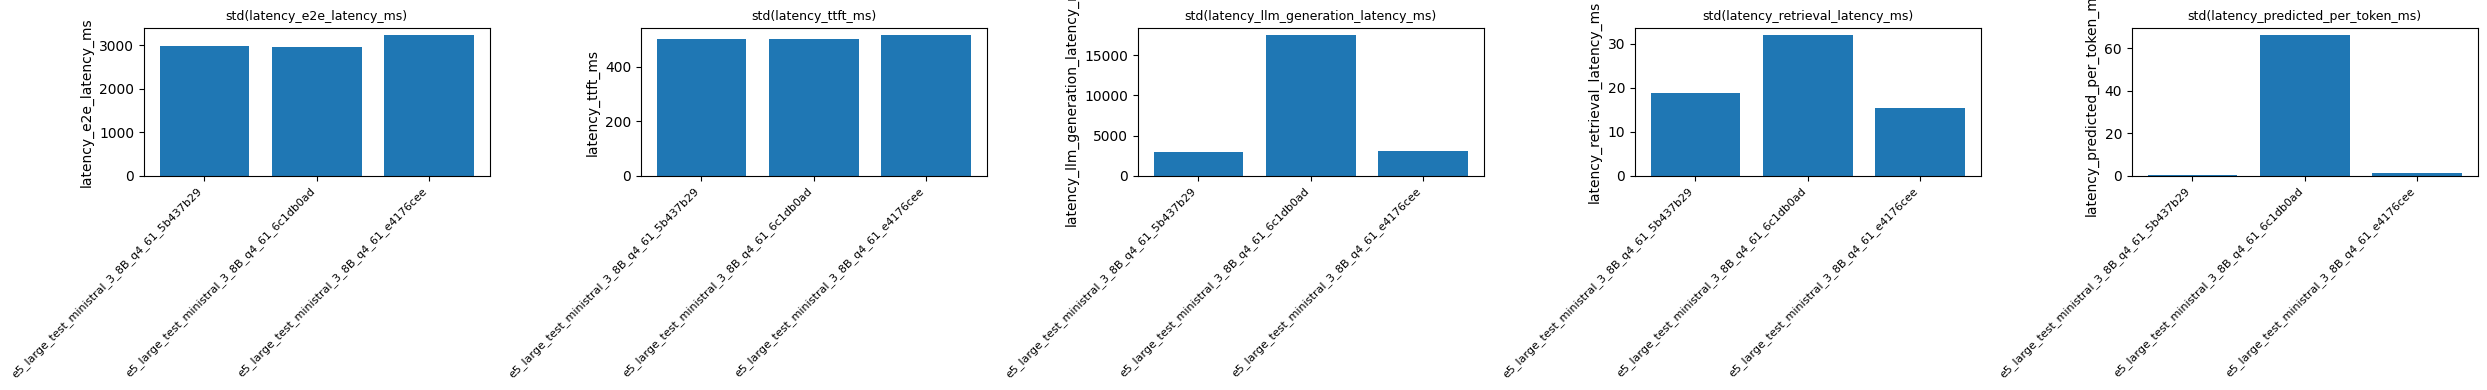

In [41]:
plot_stats_bar(df_stats, _present(df_stats, LATENCY_COLS),
               group_by="session_id", group_order=stats_sessions, stat="std")

## 4.4  Line & Multi-line Stats for One Run ID

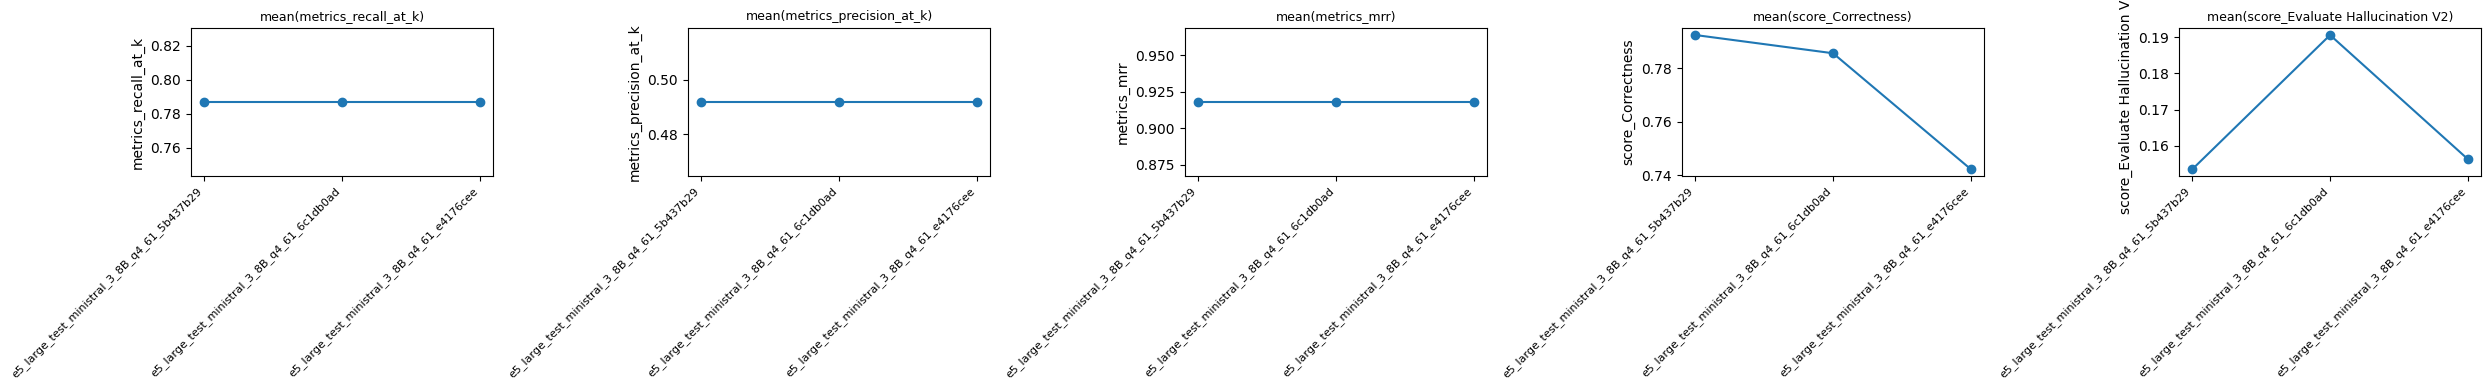

In [42]:
# Per-session mean of quality metrics for the selected run — line per metric
plot_stats_line(df_stats,
                _present(df_stats, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
                group_by="session_id", group_order=stats_sessions, stat="mean")

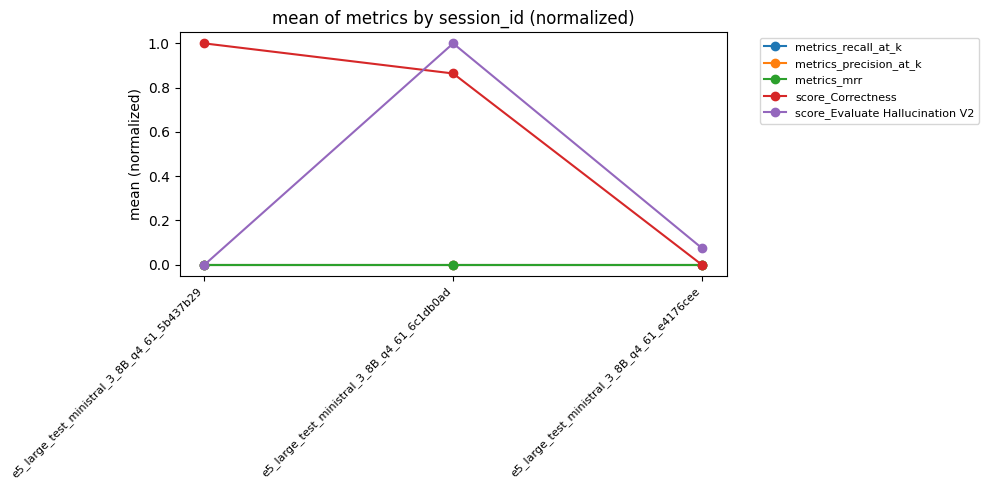

In [43]:
# All quality metrics in one plot — normalized for cross-metric comparison
plot_stats_multi_line(
    df_stats,
    _present(df_stats, RETRIEVAL_COLS + ["score_Correctness", "score_Evaluate Hallucination V2"]),
    group_by="session_id", group_order=stats_sessions,
    stat="mean", normalize=True,
)

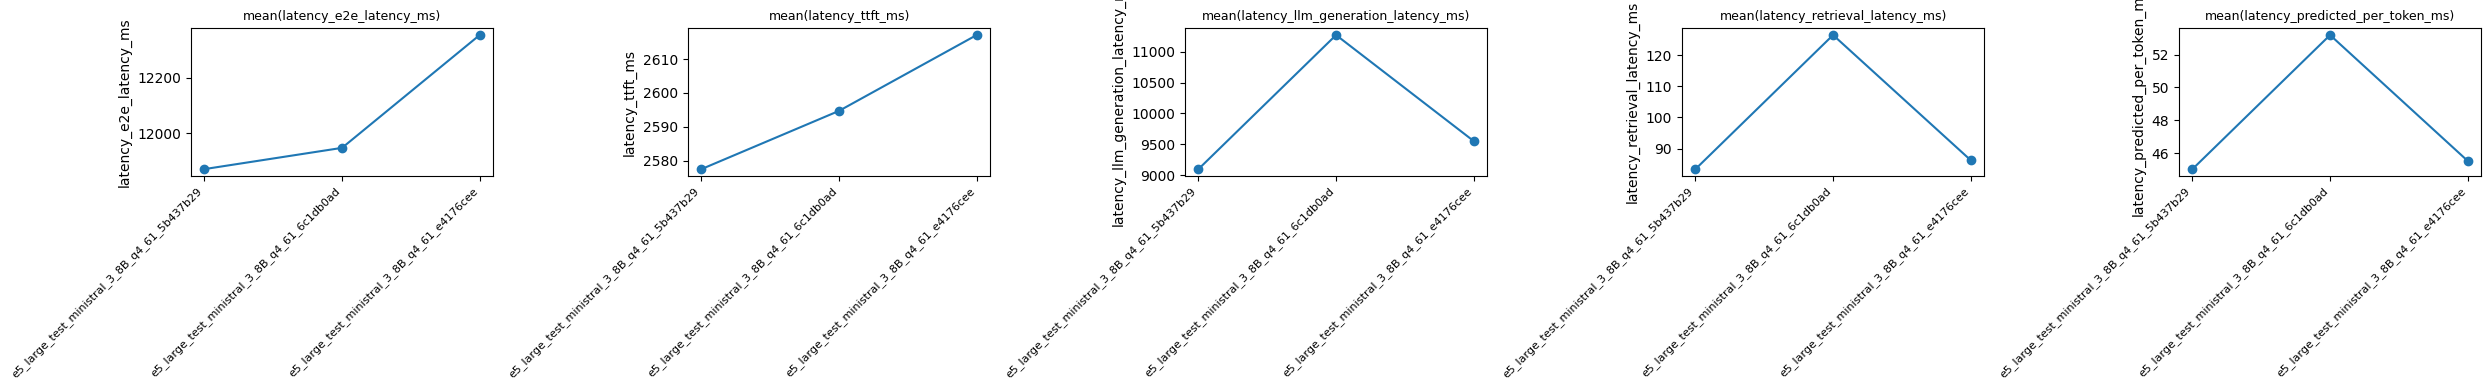

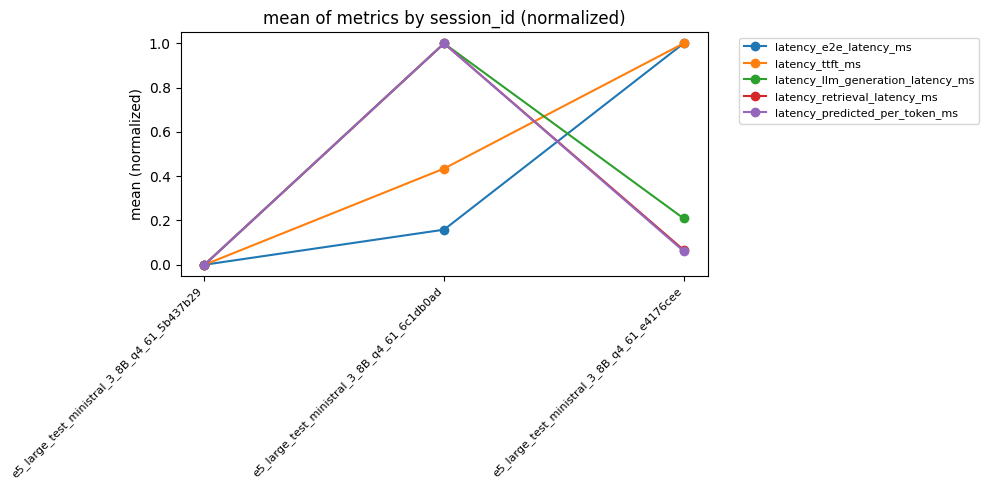

In [44]:
# Latency line plots
plot_stats_line(df_stats, _present(df_stats, LATENCY_COLS),
                group_by="session_id", group_order=stats_sessions, stat="mean")
plot_stats_multi_line(df_stats, _present(df_stats, LATENCY_COLS),
                      group_by="session_id", group_order=stats_sessions,
                      stat="mean", normalize=True)